# A Tour of PyTorch Optimizers

This notebook walks through several gradient descent optimization algorithms, giving intuition on how they work and then implementing each one in PyTorch from scratch. The learning objectives are:

- Implement SGD, SGD with momentum, Adagrad, Adadelta, RMSProp, and Adam **by hand** and understand the math behind each update rule.
- Train an MLP on Fashion-MNIST and compare training/validation loss curves across optimizers.
- Understand the trade-offs: adaptive learning rates vs. fixed rates, sensitivity to hyperparameters, and when each method shines.

### Credit to the original notebook: https://github.com/bentrevett/a-tour-of-pytorch-optimizers

> **Note:** These hand-rolled implementations are for educational purposes. In production, use `torch.optim`. There is no single "best" optimizer -- see this [paper](https://arxiv.org/abs/2007.01547). If in doubt, **Adam with default hyperparameters** is a strong starting point.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import tqdm

We'll also set the random seed, so hopefully these results can be replicated.

In [ ]:
torch.manual_seed(431)
random.seed(431)
np.random.seed(431)



All of our experiments use the Fashion-MNIST dataset, a more challenging variant of the MNIST dataset. Fashion-MNIST consists of grayscale images of clothing items (e.g., t-shirts, shoes, and coats) represented by 28×28 pixel black-and-white images, similar to MNIST. The mapping of all 0-9 integers to class labels is listed below:

- **0**: T-shirt/top  
- **1**: Trouser  
- **2**: Pullover  
- **3**: Dress  
- **4**: Coat  
- **5**: Sandal  
- **6**: Shirt  
- **7**: Sneaker  
- **8**: Bag  
- **9**: Ankle boot  


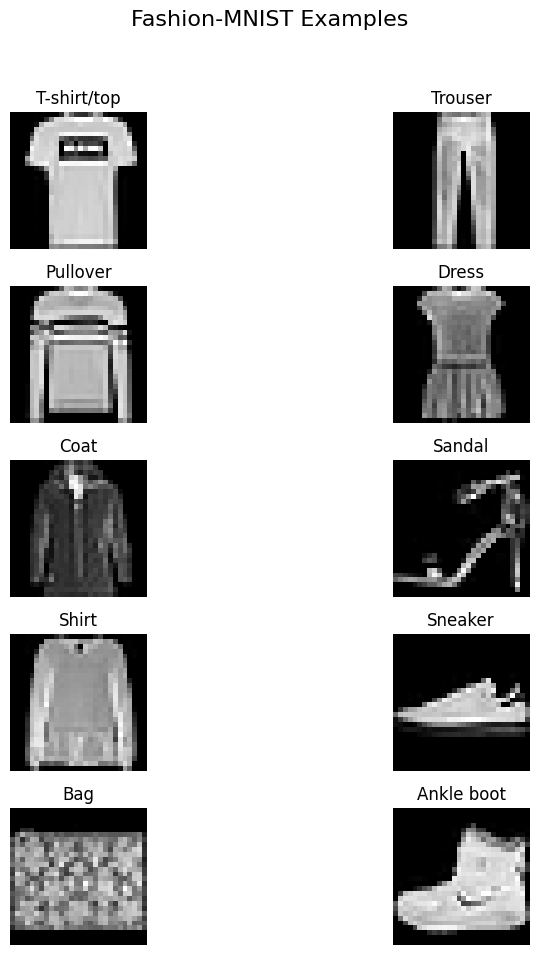

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms

# Load the Fashion-MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
dataset = datasets.FashionMNIST(root='.data', train=True, download=True, transform=transform)

# Class labels for Fashion-MNIST
class_labels = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Prepare a dictionary to store one example per class
examples = {i: None for i in range(10)}

# Find one image per class
for image, label in dataset:
    if examples[label] is None:
        examples[label] = image
    # Check if all classes have been filled with an example
    if all(v is not None for v in examples.values()):
        break

# Plotting
fig, axes = plt.subplots(5, 2, figsize=(10, 10))
fig.suptitle("Fashion-MNIST Examples", fontsize=16)

for idx, (label, ax) in enumerate(zip(examples.keys(), axes.ravel())):
    ax.imshow(examples[label].squeeze(), cmap='gray')
    ax.set_title(class_labels[label])
    ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## Split the train-validation-test data

We split the dataset into **training**, **validation**, and **test** sets. This allows us to evaluate both how well these optimizers minimize the loss and how well the architecture generalizes.
- We train the model on training data.
- Evaluate the performance of the model on validation data **during training**.
- Evaluate the final error of the model on test data.

When we load the data, we also normalize the data and do some pre-processing.

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader
import matplotlib.pyplot as plt

# Pre-computed mean and standard deviation for Fashion-MNIST
mean = 0.28604059698879553
std = 0.35302424451492237

# Define data transformations
train_transforms = transforms.Compose([
    transforms.RandomRotation(5),
    transforms.RandomCrop(28, padding=2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[mean], std=[std])
])

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[mean], std=[std])
])

# Load the full training dataset
full_train_dataset = datasets.FashionMNIST(root='.data',
                                           train=True,
                                           download=True,
                                           transform=train_transforms)

# Split the training dataset into training and validation sets (80% train, 20% validation)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Load the test dataset
test_dataset = datasets.FashionMNIST(root='.data',
                                     train=False,
                                     download=True,
                                     transform=test_transforms)


# Print sizes of the splits to verify
print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Training set size: 48000
Validation set size: 12000
Test set size: 10000


## We then create the iterator for the data using `DataLoader`.


The `DataLoader` is used to iterate through the dataset in mini-batches, which are smaller, more manageable portions of the data. It allows you to efficiently train your model without needing to load the entire dataset into memory. Here’s how to use it and what it returns:

1. **Initialization**:
   - You create an instance of `DataLoader` by passing in your dataset (`train_dataset`, `val_dataset`, or `test_dataset`), specifying the `batch_size`, whether you want to `shuffle` the data, and optionally setting the `num_workers` parameter.
   
   ```python
   train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
   ```

2. **Iterating through the Data**:
   - Once the `DataLoader` is initialized, you can iterate over it using a `for` loop. Each iteration returns a mini-batch of data (a tuple containing images and labels).
   
   ```python
   for images, labels in train_loader:
       # Training code goes here
   ```
   
   - This loop will continue until all the mini-batches in the dataset have been processed. At the end of each epoch, the `DataLoader` reshuffles the data (if `shuffle=True` is set), ensuring that the model sees the data in a different order in the next epoch.

3. **What It Returns**:
   - The `DataLoader` returns a **mini-batch** of data consisting of:
     - **Images**: A tensor containing a batch of images. The shape of this tensor is `[batch_size, channels, height, width]`. For example, if the batch size is 64, each image is 1 channel (grayscale) and 28×28 pixels, the shape would be `[64, 1, 28, 28]`.
     - **Labels**: A tensor of the corresponding labels for each image in the batch. The shape of this tensor is `[batch_size]`. For instance, with a batch size of 64, the labels tensor would have the shape `[64]`.

4. **Practical Example**:
   - When iterating over `train_loader`, you can use the images and labels tensors directly to pass them through your neural network model:
   
   ```python
   for images, labels in train_loader:
       outputs = model(images)  # Forward pass
       loss = criterion(outputs, labels)  # Calculate the loss
       loss.backward()  # Backward pass for gradient computation
       optimizer.step()  # Update model parameters
       optimizer.zero_grad()  # Reset gradients for the next batch
   ```

This structure is highly efficient and crucial for mini-batch gradient descent, enabling faster computation and convergence during training.

In [ ]:

# Create data loaders for training, validation, and testing
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)



## Build a Neural Network

 Next, we'll define our architecture: a multi-layer perceptron (MLP) with three hidden layers. Each hidden layer is followed by a ReLU activation function to introduce non-linearity, allowing the network to learn complex patterns in the data. The final layer produces logits for the 10 classes, and a `log_softmax` function is applied to output log probabilities.

- **Input Layer**: The input is a flattened version of the 28×28 pixel grayscale image, resulting in an input dimension of 784.
- **Hidden Layers**: We define three fully connected layers:
  - The first layer (`fc1`) maps the 784-dimensional input to 392 dimensions.
  - The second layer (`fc2`) reduces it to 196 dimensions.
  - The third layer (`fc3`) reduces it further to 98 dimensions.
- **Output Layer**: The final layer (`output`) maps the 98-dimensional output to the 10 classes, corresponding to the categories in the Fashion-MNIST dataset.

### Initialization

The `init_params` function can be called to initialize the weights using the "Kaiming" (also known as "He") initialization scheme. This method works well when using the ReLU activation function as it helps maintain a good variance in the forward pass, preventing vanishing or exploding gradients. The biases are initialized to zeros, which is a common practice.

The initialization scheme can impact the performance and results of the optimizers. The choice of "Kaiming" initialization is suitable in this case due to its compatibility with ReLU activations, ensuring stable training.

By constructing the network and initializing the parameters appropriately, we set the foundation for training a model capable of classifying images from the Fashion-MNIST dataset.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class MLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dims=[392, 196, 98], output_dim=10):
        super().__init__()
        # Define layers
        self.fc1 = nn.Linear(input_dim, hidden_dims[0])
        self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.fc3 = nn.Linear(hidden_dims[1], hidden_dims[2])
        self.output = nn.Linear(hidden_dims[2], output_dim)

        # Initialize parameters
        self.init_params()

    def init_params(self):
        for name, param in self.named_parameters():
            if 'weight' in name:
                nn.init.kaiming_normal_(param, nonlinearity='relu')
            elif 'bias' in name:
                nn.init.constant_(param, 0)

    def forward(self, x):
        # x = [batch size, channels, height, width]
        batch_size, *_ = x.shape
        x = x.view(batch_size, -1)  # Flatten the input
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.output(x)
        x = F.log_softmax(x, dim=1)
        return x


In [ ]:
input_dim = 28 * 28
hidden_dims=[392, 196, 98]
output_dim = 10

model = MLP(input_dim, hidden_dims, output_dim)

### Visualize this three layer NN

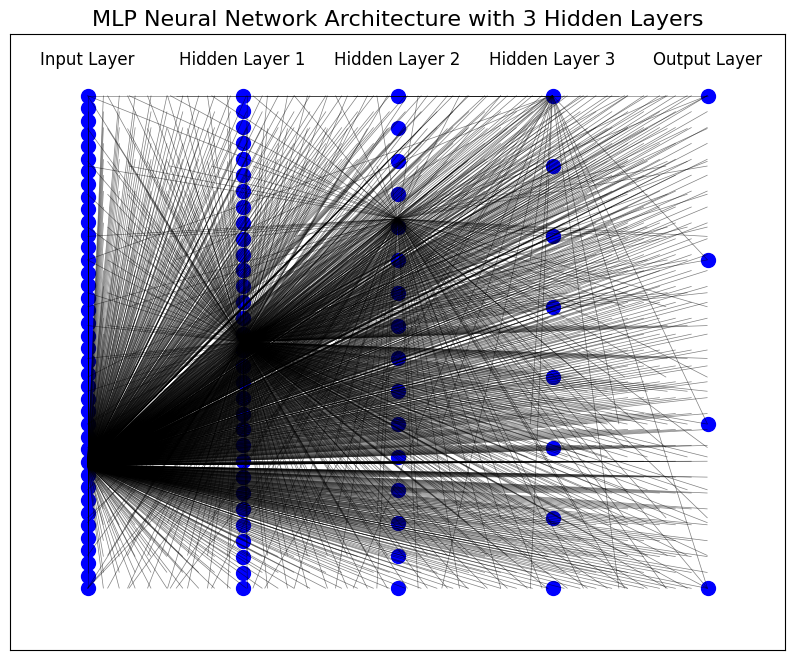

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection

def visualize_network():
    # Define the architecture
    layer_sizes = [40, 32, 16, 8, 4]
    layer_labels = ['Input Layer', 'Hidden Layer 1', 'Hidden Layer 2', 'Hidden Layer 3', 'Output Layer']

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.set_title('MLP Neural Network Architecture with 3 Hidden Layers', fontsize=16)

    # Horizontal positions of layers
    x_positions = np.linspace(0.1, 0.9, len(layer_sizes))
    y_min, y_max = 0.1, 0.9  # Min and max vertical range for nodes

    # Store all lines for LineCollection
    lines = []

    # Iterate over layers to plot nodes and connections
    for i, (layer_size, x_pos) in enumerate(zip(layer_sizes, x_positions)):
        y_positions = np.linspace(y_min, y_max, layer_size)
        ax.scatter([x_pos] * layer_size, y_positions, s=100, color='blue', zorder=2)
        ax.text(x_pos, y_max + 0.05, layer_labels[i], ha='center', fontsize=12, zorder=3)

        # Collect connections between this layer and the next layer
        if i < len(layer_sizes) - 1:
            next_y_positions = np.linspace(y_min, y_max, layer_sizes[i + 1])
            # Use a subset of nodes or all nodes for connections
            lines += [([x_pos, x_positions[i + 1]], [y1, y2]) for y1 in y_positions for y2 in next_y_positions]

    # Create a LineCollection for faster plotting
    line_collection = LineCollection(lines, colors='black', linewidths=0.5, alpha=0.5)
    ax.add_collection(line_collection)

    # Turn off axis
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    plt.show()

# Call the function to visualize the network
visualize_network()


 ## Define the Loss Function and Optimizer

Once the neural network is defined, the next step is to set up the loss function and the optimizer. Additionally, to leverage the computational power of the GPU, we must ensure that the model and the data are moved to the GPU if available.

### 1. Setting Up the Device

We first check if a GPU is available using `torch.cuda.is_available()`:
- If available, we set the device to `cuda` for GPU computation.
- Otherwise, we set it to `cpu`.
  
```python
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
```

### 2. Moving the Model to the Device

We initialize the model and use the `.to(device)` method to move it to the appropriate device (either the GPU or the CPU). This ensures that all computations performed with the model are carried out on the selected device.

```python
model = MLP().to(device)
```

### 3. Defining the Loss Function

We use **Cross-Entropy Loss** (`nn.CrossEntropyLoss`), which is the standard loss function for multi-class classification problems. This loss function calculates the difference between the predicted class probabilities and the true labels, making it suitable for tasks like classifying Fashion-MNIST images.

```python
criterion = nn.CrossEntropyLoss()
```

### 4. Setting Up the Optimizer

For optimizing the model's parameters, we use **Stochastic Gradient Descent (SGD)** with a learning rate of 0.01 and a momentum of 0.9. Momentum helps accelerate convergence and stabilize updates.

```python
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
```

### 5. Using the Model and Loss Function with the Device

- In the `train_step` function, we move both the images and labels to the device using `.to(device)` so that the computations occur on the GPU (if available).
- We perform a **forward pass**, calculate the loss, and then perform the **backward pass** to compute gradients.
- Finally, we call `optimizer.step()` to update the model parameters based on the computed gradients.

By ensuring that both the model and data are on the same device (GPU or CPU), we can efficiently train our neural network while taking advantage of available hardware accelerations.


### In the following, we are going to implement the algorithms on our own.

In [ ]:
print(f"cuda is available? {torch.cuda.is_available()}")  # Should return True if GPU is available
print(f"number of GPUs: {torch.cuda.device_count()}")  # Number of GPUs available
print(f"name of GPUs: {torch.cuda.get_device_name(0)}")  # Name of the first GPU (if available)

# Check if GPU is available and set the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\nUsing device: {device}')

# Initialize the model and move it to the device
model = MLP().to(device)

# Define the loss function (Cross-Entropy Loss for multi-class classification)
criterion = nn.CrossEntropyLoss()


cuda is available? True
number of GPUs: 1
name of GPUs: NVIDIA A100 80GB PCIe

Using device: cuda


# Define our Optimizers


Next, we'll define some functions for training the model with our optimizers and plotting the results.

### `train_and_evaluate`

The `train_and_evaluate` function is designed to train a neural network model and evaluate its performance over a specified number of epochs. It uses the training and validation datasets to track the progress of the model.

#### Parameters
- **`model`**: The neural network model to be trained.
- **`train_iterator`**: A `DataLoader` object that provides batches of training data.
- **`val_iterator`**: A `DataLoader` object that provides batches of validation data.
- **`optimizer`**: The optimizer used for updating model parameters, e.g., SGD, Adam.
- **`criterion`**: The loss function, such as Cross-Entropy Loss, used to calculate the error between predictions and actual labels.
- **`device`**: The device (`'cpu'` or `'cuda'`) on which the model and data will be processed.
- **`n_epochs`**: (default = 5) The number of epochs to train the model. An epoch is a full pass through the entire training dataset.

#### Returns
- **`train_losses`**: A list containing the average training loss for each epoch.
- **`val_losses`**: A list containing the average validation loss for each epoch.
- **`val_accuracies`**: A list containing the average validation accuracy for each epoch.

- The function first initializes the model parameters using `model.init_params()`.
- For each epoch:
  - The model is set to training mode (`model.train()`), and it iterates over the training data, calculating the loss, performing backpropagation, and updating the model’s parameters using the optimizer.
  - After the training phase, the model switches to evaluation mode (`model.eval()`) to compute the validation loss. The validation data is passed through the model without updating parameters (no gradients are computed).
- The function returns three lists: `train_losses`, `val_losses`, and `val_accuracies`, which store the average training and validation loss and validation accuracy for each epoch.


In [ ]:
def train_and_evaluate(model, train_iterator, val_iterator, optimizer, criterion, device, n_epochs=25):
    """Trains the model and evaluates it over the given epochs, returning training and validation losses."""

    train_losses = []
    val_losses = []
    val_accuracies = []

    # Initialize model parameters
    model.init_params()
    model.to(device)

    for epoch in range(n_epochs):
        # Training phase
        model.train()  # Set model to training mode
        step_train_losses = []  # To store training losses at each step

        for images, labels in tqdm.tqdm(train_iterator, desc=f"Training Epoch {epoch+1}/{n_epochs}"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            predictions = model(images)
            loss = criterion(predictions, labels)
            loss.backward()
            optimizer.step()
            step_train_losses.append(loss.item())  # Save the loss at each step

        # Calculate average training loss for the epoch
        avg_train_loss = sum(step_train_losses) / len(step_train_losses)
        train_losses.extend(step_train_losses)  # Save all step losses
        print(f"Epoch: {epoch+1} -> train_loss: {avg_train_loss:.4f}")

        # Validation phase
        model.eval()  # Set model to evaluation mode
        step_val_losses = []  # To store validation losses at each step
        correct_predictions = 0
        total_predictions = 0
        with torch.no_grad():
            for images, labels in tqdm.tqdm(val_iterator, desc=f"Validation Epoch {epoch+1}/{n_epochs}"):
                images, labels = images.to(device), labels.to(device)
                predictions = model(images)
                loss = criterion(predictions, labels)
                step_val_losses.append(loss.item())  # Save the loss at each step

                # Calculate accuracy
                _, predicted_classes = torch.max(predictions, 1)
                correct_predictions += (predicted_classes == labels).sum().item()
                total_predictions += labels.size(0)

        # Calculate average validation loss for the epoch
        avg_val_loss = sum(step_val_losses) / len(step_val_losses)
        val_losses.extend(step_val_losses)  # Save all step losses

        # Calculate validation accuracy
        val_accuracy = 100 * correct_predictions / total_predictions
        val_accuracies.append(val_accuracy)

        # Print epoch results
        print(f"Epoch: {epoch+1} -> val_loss: {avg_val_loss:.4f}, val_acc: {val_accuracy:.2f}%")

    return train_losses, val_losses, val_accuracies



### `plot_train_val_loss`

The `plot_train_val_loss` function visualizes the loss curves for both the training and validation processes, helping to understand the model’s behavior over epochs.

#### Parameters
- **`train_loss`**: A list of training loss values for each epoch, as returned by `train_and_evaluate`.
- **`val_loss`**: A list of validation loss values for each epoch, as returned by `train_and_evaluate`.
- **`title`**: (optional) A string for the title of the plot.
- **`ymin`**: (default = 0) The minimum value of the y-axis.
- **`ymax`**: (optional) The maximum value of the y-axis.
- **`figsize`**: (default = (10, 5)) The size of the figure.

#### Description
- The function creates a plot with two curves: one for the training loss and one for the validation loss, both plotted against the epochs.
- The x-axis represents the number of epochs, while the y-axis represents the loss value.
- The function includes labels for the axes, a grid for clarity, and a legend indicating which curve corresponds to training and which to validation.
- The function displays the plot, allowing you to visually assess how well the model is performing on the training and validation sets over time.

These functions work together to train a model while tracking its performance and visualizing its progress over the training period.

In [ ]:
import matplotlib.pyplot as plt

def plot_train_val_metrics(train_loss, val_loss, val_accuracy, option=1, title=None, ymin=0, ymax=None, figsize=(15, 5)):
    """Plots the training and validation loss curves, and the validation accuracy curve."""

    if option == 1:
        # Option 1: Plot training and validation losses on the same figure and validation accuracy on another figure
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

        # Plot training and validation loss
        ax1.plot(train_loss, label='Training Loss')
        ax1.plot(val_loss, label='Validation Loss')
        ax1.set_title(title or 'Training and Validation Loss')
        ax1.set_ylabel('Loss')
        ax1.set_xlabel('Epochs')
        ax1.set_ylim(ymin=ymin, ymax=ymax)
        ax1.grid(True)
        ax1.legend(loc='upper right')

        # Plot validation accuracy
        ax2.plot(val_accuracy, label='Validation Accuracy', color='green')
        ax2.set_title('Validation Accuracy')
        ax2.set_ylabel('Accuracy (%)')
        ax2.set_xlabel('Epochs')
        ax2.set_ylim(0, 100)
        ax2.grid(True)
        ax2.legend(loc='lower right')

        plt.tight_layout()
        plt.show()

    elif option == 2:
        # Option 2: Plot three figures in the same row
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=figsize)

        # Plot training loss
        ax1.plot(train_loss, label='Training Loss')
        ax1.set_title('Training Loss')
        ax1.set_ylabel('Loss')
        ax1.set_xlabel('Steps')
        ax1.set_ylim(ymin=ymin, ymax=ymax)
        ax1.grid(True)

        # Plot validation loss
        ax2.plot(val_loss, label='Validation Loss', color='orange')
        ax2.set_title('Validation Loss')
        ax2.set_ylabel('Loss')
        ax2.set_xlabel('Steps')
        ax2.set_ylim(ymin=ymin, ymax=ymax)
        ax2.grid(True)

        # Plot validation accuracy
        ax3.plot(val_accuracy, label='Validation Accuracy', color='green')
        ax3.set_title('Validation Accuracy')
        ax3.set_ylabel('Accuracy (%)')
        ax3.set_xlabel('Steps')
        ax3.set_ylim(0, 100)
        ax3.grid(True)

        plt.tight_layout()
        plt.show()

    else:
        print("Invalid option. Choose either 1 or 2.")


## Now let's implement our first optimizer!

## Optimizer 1: Stochastic Gradient Descent (SGD)

Stochastic gradient descent is the simplest optimization algorithm, so it's a good place to start. We take our current model parameters $\theta_t$ and subtract the gradient of those parameters, $\nabla_\theta J(\theta_t)$, multiplied by the "learning rate", $\eta$.

We can think of the learning rate as a parameter that controls the magnitude of the parameter update. If our learning rate is too small then our parameter updates will also be too small for us to train our model in a reasonable amount of time. Conversely, if our learning rate is too large then the size of the parameter updates will be so large that learning will become unstable! If you ever get a `NaN` value for your loss, one of the first things to try would be lowering the learning rate.

The SGD algorithm is:

$$\theta_{t+1} = \theta_t - \eta \cdot \nabla_\theta J(\theta_t)$$

However, we don't just have one set of parameters, $\theta$, we have multiple parameters: the weights of layer 1, the biases of layer 1, the weights of layer 2, the biases of layer 2, etc. So we'll subscript the parameters with $i$:

$$\theta_{t+1,i} = \theta_{t,i} - \eta \cdot \nabla_\theta J(\theta_{t,i})$$

We subtract because we want to descend the gradient and move towards a lower loss value. Addition would ascend the gradient, hence it's called gradient ascent.

One final thing to mention is the difference gradient descent, stochastic gradient descent, mini-batch gradient descent and on-line gradient descent. **Gradient descent** means we calculate the gradient using every single example in our training set and then do a single parameter update. This is relatively slow as in our experiments it means only updating the parameters after seeing all 60,000 examples. The other extreme is **stochastic gradient descent** which means we update our parameters after every single example. This is usually very noisy, so a happy medium is updating the parameters after we have seen a *batch* of examples,  **mini-batch gradient descent**. Last up is **on-line gradient descent** which usually implies our model is in production and is being constantly fed new examples on which it is using to update its parameters.

Confusingly, **gradient descent** is sometimes called **batch gradient descent**, where the whole dataset counts as one giant batch, hence why using sampled batch of examples is called a *mini-batch*.

In PyTorch, the optimizer is called *stochastic gradient descent* even though it can do any of the above gradient descent variants. The general rule of thumb is that nowadays when someone mentions stochastic gradient descent then they mean mini-batch gradient descent.

Anyway, on to the implementation. All optimizers need a way of keeping track of the parameters they're supposed to be updating `model_params` and a learning rate, `lr`. SGD in PyTorch doesn't have a default learning rate but `1e-3` is a common default learning rate value for other optimizers, so we use it here. All optimizers need a `zero_grad` function in order to remove the gradients calculated from the last update step, and a `step` function to perform a parameter update.

Note that any PyTorch method with a trailing underscore, e.g., `.sub_`, means the operation is in-place. This means ourour `step` function is updating each `param`, a tensor of parameters, in-place. These in-place operations are usually significantly faster non in-place operations.

In [ ]:
class SGD:
    def __init__(self, model_params, lr=1e-3):
        self.model_params = list(model_params)
        self.lr = lr

    def zero_grad(self):
        for param in self.model_params:
            param.grad = None

    @torch.no_grad()
    def step(self):
        for param in self.model_params:
            param.sub_(self.lr * param.grad)

We can define our optimizer like so:

In [ ]:
optimizer = SGD(model.parameters())

Then we use this optimizer to minimize the loss.

In [ ]:
sgd_train_losses, sgd_val_losses, sgd_val_accuracies = train_and_evaluate(model, train_loader, val_loader, optimizer, criterion, device, n_epochs=10)

Training Epoch 1/10: 100%|██████████| 188/188 [00:09<00:00, 20.50it/s]


Epoch: 1 -> train_loss: 1.9643


Validation Epoch 1/10: 100%|██████████| 94/94 [00:02<00:00, 41.10it/s]


Epoch: 1 -> val_loss: 1.5540, val_acc: 47.67%


Training Epoch 2/10: 100%|██████████| 188/188 [00:09<00:00, 20.58it/s]


...

Epoch: 9 -> val_loss: 0.8275, val_acc: 69.77%


Training Epoch 10/10: 100%|██████████| 188/188 [00:09<00:00, 20.62it/s]


Epoch: 10 -> train_loss: 0.8251


Validation Epoch 10/10: 100%|██████████| 94/94 [00:02<00:00, 41.04it/s]

Epoch: 10 -> val_loss: 0.8081, val_acc: 70.05%


### Now let's plot the losses

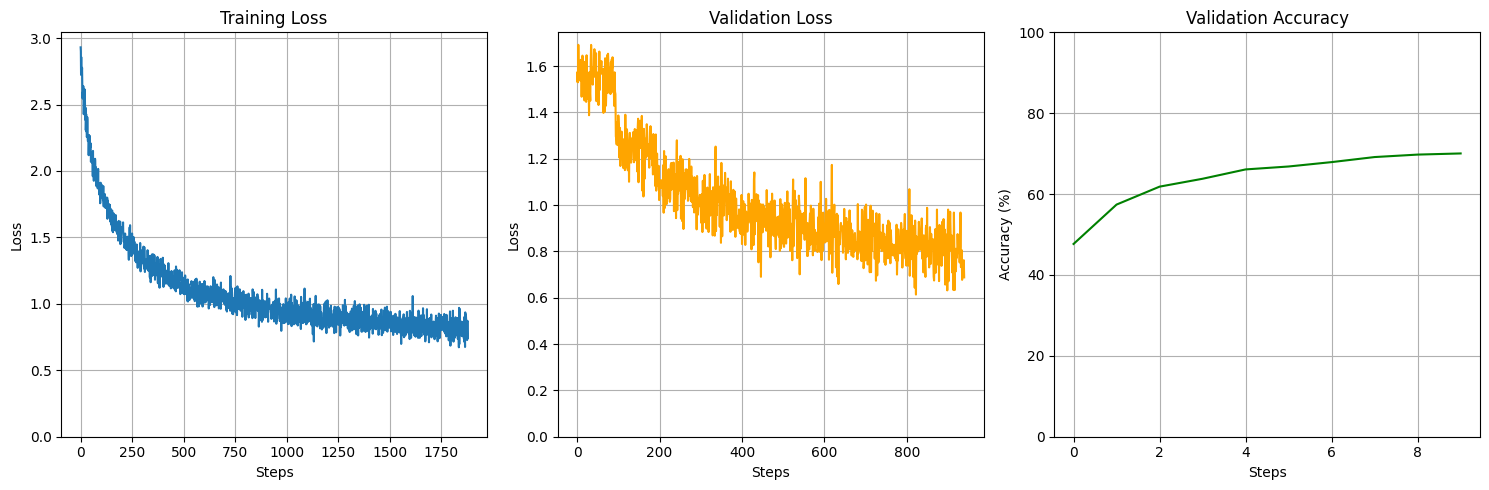

In [ ]:
plot_train_val_metrics(sgd_train_losses, sgd_val_losses, sgd_val_accuracies, option=2, title="SGD Training and Validation Metrics")


Looks reasonable, the loss starts at a high value as our parameters are randomly initialized and then proceeds to decrease steadily. We can't really tell how "good" it is without comparing it against another optimizer, so let's go ahead and do that now.

## Optimizer 2: SGD with Momentum

One way to think of SGD is a ball rolling down a hill, where areas of high gradient are steep parts of the hill and areas of low gradient are very flat areas. Sometimes the global minima, the point with the lowest loss, is in the middle of a giant flat area. The problem is that because these flat areas have small gradients they also give small update steps which makes learning slow.

What if we expanded on the "ball rolling down a hill" analogy? We'd want to add something to our optimizer that made it keep the "momentum" gained rolling down the steep hills whilst it's going across the flat areas.

Well hey, that's exact what SGD with momentum does! Our parameter update is now calculated using a velocity, $v$, which depends on the current gradient multiplied by the learning rate plus the previous velocity multiplied by the momentum $\gamma$.

\begin{align*}
    v_{t,i} &= \gamma \cdot v_{t-1,i} + \eta \cdot \nabla_\theta J(\theta_{t,i})\\
    \theta_{t+1,i} &= \theta_{t,i} - v_{t,i}\\
\end{align*}

If momentum is zero then we don't care about the previous velocity at all and this algorithm becomes SGD. Commonly used momentum values are usually around 0.9ish.

PyTorch's optimizers are sometimes a little different from the actual algorithms. PyTorch's version of SGD with momentum moves the learning rate outside the equation for velocity:

\begin{align*}
    v_{t,i} &= \gamma \cdot v_{t-1,i} + \nabla_\theta J(\theta_{t,i})\\
    \theta_{t+1,i} &= \theta_{t,i} - \eta \cdot v_{t,i}\\
\end{align*}

If the PyTorch implementation differs then we'll implement the PyTorch version as we use it as a reference.

Note that the velocity `v` is a list of tensors corresponding to the model parameters, so we are storing the velocity of every single parameter in our model.

In [ ]:
class SGDMomentum:
    def __init__(self, model_params, lr=1e-3, momentum=0.9):
        self.model_params = list(model_params)
        self.lr = lr
        self.momentum = momentum
        self.v = [torch.zeros_like(p) for p in self.model_params]

    def zero_grad(self):
        for param in self.model_params:
            param.grad = None

    @torch.no_grad()
    def step(self):
        for param, v in zip(self.model_params, self.v):
            v.mul_(self.momentum).add_(param.grad)
            param.sub_(self.lr * v)

Below we define our SGD with momentum optimizer, train our model and plot the results.

In [ ]:
optimizer = SGDMomentum(model.parameters())

In [ ]:
momentum_train_losses, momentum_val_losses, momentum_val_accuracies = train_and_evaluate(model, train_loader, val_loader, optimizer, criterion, device, n_epochs=10)

Training Epoch 1/10: 100%|██████████| 188/188 [00:09<00:00, 20.54it/s]


Epoch: 1 -> train_loss: 1.1283


Validation Epoch 1/10: 100%|██████████| 94/94 [00:02<00:00, 41.01it/s]


Epoch: 1 -> val_loss: 0.8109, val_acc: 70.60%


Training Epoch 2/10: 100%|██████████| 188/188 [00:09<00:00, 20.39it/s]


...

Epoch: 9 -> val_loss: 0.5611, val_acc: 79.08%


Training Epoch 10/10: 100%|██████████| 188/188 [00:09<00:00, 20.60it/s]


Epoch: 10 -> train_loss: 0.5548


Validation Epoch 10/10: 100%|██████████| 94/94 [00:02<00:00, 40.94it/s]

Epoch: 10 -> val_loss: 0.5578, val_acc: 79.26%


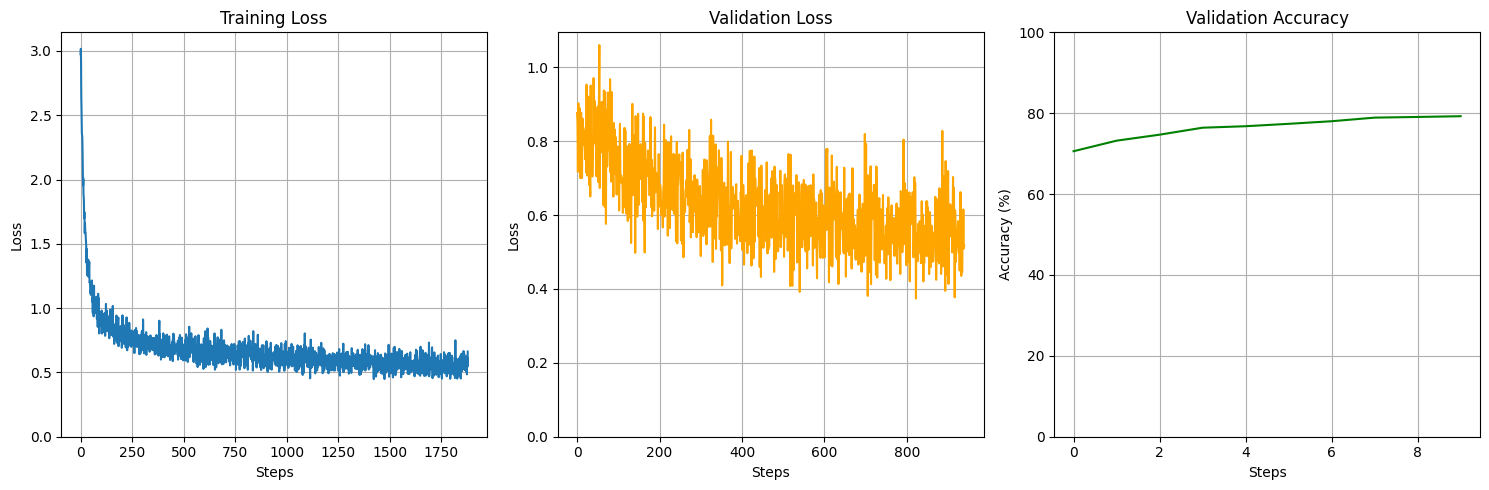

In [ ]:
plot_train_val_metrics(momentum_train_losses, momentum_val_losses, momentum_val_accuracies, option=2, title='SGDMomentum with lr=1e-3, momentum=0.9')

Now let's compare SGD and SGD with momentum.

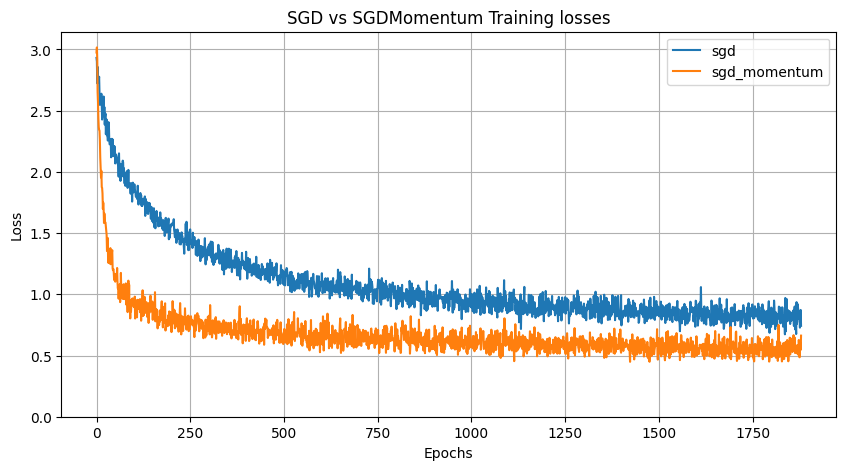

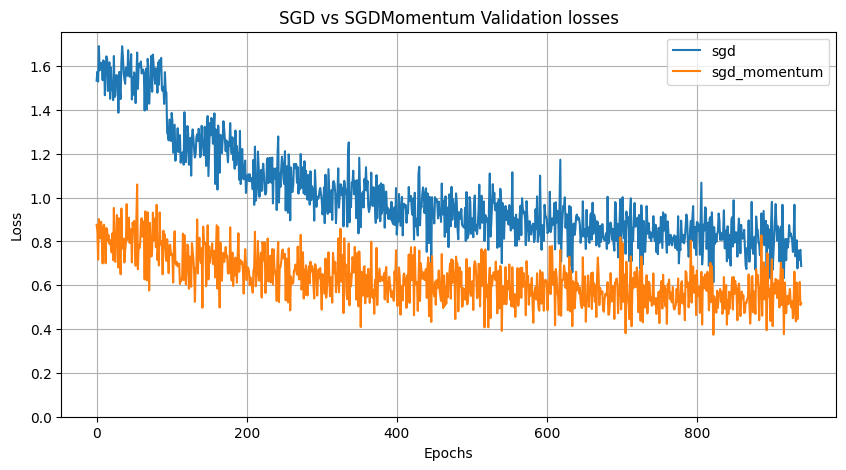

In [ ]:
def plot_losses(losses, labels, title=None, ymin=0, ymax=None, figsize=(10, 5)):
    """Plots multiple training or validation losses on the same figure for comparison."""

    fig, ax = plt.subplots(figsize=figsize)
    for loss, label in zip(losses, labels):
        ax.plot(loss, label=label)

    ax.set_title(title or 'Comparison of Losses')
    ax.set_ylabel('Loss')
    ax.set_xlabel('Epochs')
    ax.set_ylim(ymin=ymin, ymax=ymax)
    ax.grid(True)
    ax.legend(loc='upper right')
    plt.show()


train_losses = [sgd_train_losses, momentum_train_losses]
labels = ['sgd', 'sgd_momentum']

plot_losses(train_losses, labels, 'SGD vs SGDMomentum Training losses')


val_losses = [sgd_val_losses, momentum_val_losses]
plot_losses(val_losses, labels, 'SGD vs SGDMomentum Validation losses')

As we can see, not only does momentum help us reach the lowest SGD loss, around 1.0, in a fraction of the time it also gives us a lower overall!

There's also another variant of SGD with momentum called **Nesterov Accelerated Gradient** (NAG) but we aren't going to implement it here for a few reasons:

1. There are multiple different ways to implement it, see [this](https://jlmelville.github.io/mize/nesterov.html) excellent article for details on the variations, and PyTorch implements it in a completely different way.
2. I have personally found that it has never provided a noticable improvement over regular momentum.
3. It's not very commonly used.

Let's move on to the next optimizer.

## Optimizer 3: Adagrad

One downside with SGD is that we use a single learning rate across all of our parameters, and that this learning rate is fixed through the entirety of training.

Ideally, parameters that are updated more frequently have a lower learning rate and parameters that are updated infrequently have a larger learning rate.

This is what Adagrad does. We use $G_{t,i}$ which is the sum of the squared gradients for parameter $i$ up to, and including, time-step $t$. $G_{t,i}$ is initialized to some value, usually zero by default. As the square of the gradients of a parameter are accumulated, $G_{t,i}$ increases, and thus reduces the learning rate for parameter $i$.

$$\theta_{t+1,i} = \theta_{t,i} - \frac{\eta}{\sqrt{G_{t,i}}+\epsilon} \cdot \nabla_\theta J(\theta_{t,i})$$

where:

$$G_{t,i} = G_{t-1,i} + \Big(\nabla_\theta J(\theta_{t,i})\Big)^2$$

$\epsilon$ is very small number, used to avoid division by zero in the denominator. Sometimes you'll see $\epsilon$ inside the square root, and sometimes it will be outside. PyTorch leaves it outside so we will too.

We implement Adagrad below, initializing $G$ as a list of tensors called `acc_sqr_grads` and using `std` to refer to the denominator of the update step equation.

In [ ]:
class Adagrad:
    def __init__(self, model_params, lr=1e-2, init_acc_sqr_grad=0, eps=1e-10):
        self.model_params = list(model_params)
        self.lr = lr
        self.acc_sqr_grads = [torch.full_like(p, init_acc_sqr_grad) for p in self.model_params]
        self.eps = eps

    def zero_grad(self):
        for param in self.model_params:
            param.grad = None

    @torch.no_grad()
    def step(self):
        for param, acc_sqr_grad in zip(self.model_params, self.acc_sqr_grads):
            acc_sqr_grad.add_(param.grad * param.grad)
            std = acc_sqr_grad.sqrt().add(self.eps)
            param.sub_((self.lr / std) * param.grad)

In [ ]:
optimizer = Adagrad(model.parameters())

In [ ]:
adagrad_train_losses, adagrad_val_losses, adagrad_val_accuracies =  train_and_evaluate(model, train_loader, val_loader, optimizer, criterion, device, n_epochs=10)

Training Epoch 1/10: 100%|██████████| 188/188 [00:09<00:00, 20.18it/s]


Epoch: 1 -> train_loss: 0.9449


Validation Epoch 1/10: 100%|██████████| 94/94 [00:02<00:00, 40.40it/s]


Epoch: 1 -> val_loss: 0.6145, val_acc: 75.82%


Training Epoch 2/10: 100%|██████████| 188/188 [00:09<00:00, 20.22it/s]


...

Epoch: 9 -> val_loss: 0.4191, val_acc: 84.38%


Training Epoch 10/10: 100%|██████████| 188/188 [00:09<00:00, 20.28it/s]


Epoch: 10 -> train_loss: 0.3981


Validation Epoch 10/10: 100%|██████████| 94/94 [00:02<00:00, 40.95it/s]

Epoch: 10 -> val_loss: 0.4103, val_acc: 84.56%


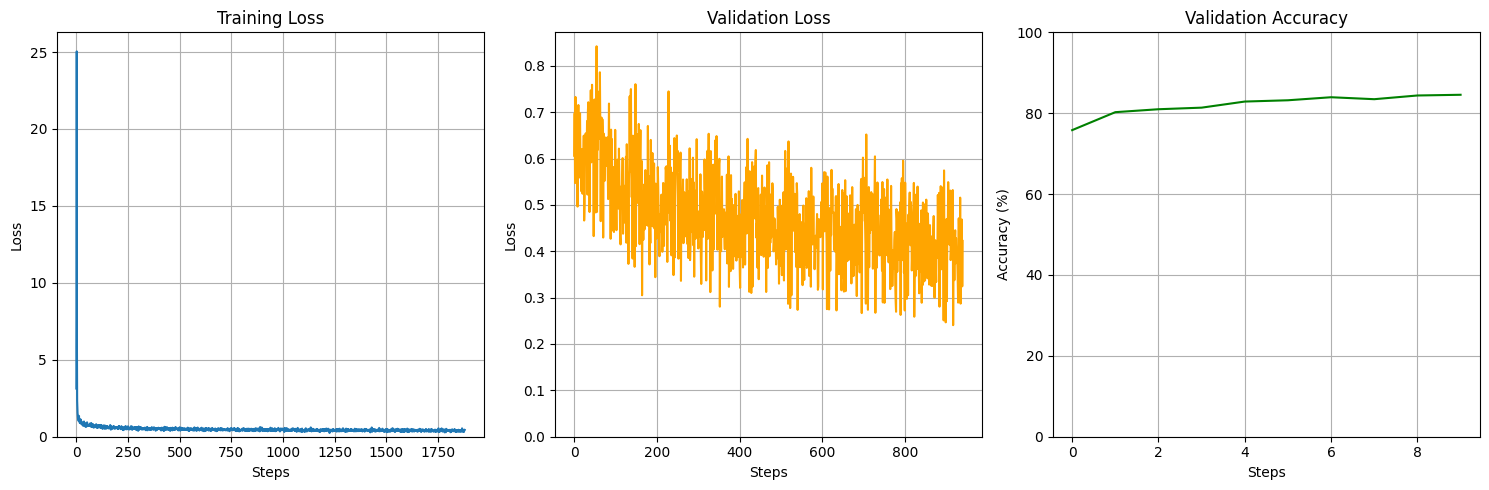

In [ ]:
plot_train_val_metrics(adagrad_train_losses, adagrad_val_losses, adagrad_val_accuracies, option=2, title='Adagrad with lr=1e-2, init_acc_sqr_grad=0,eps=1e-10')

We can see there's an initial large spike in the loss value. This is due to the initial $G$ values being very small and thus the learning rate is divided by a very small number making it very large. Very large learning rates usually lead to unstable training which give higher loss values.

Let's trim down the figure.


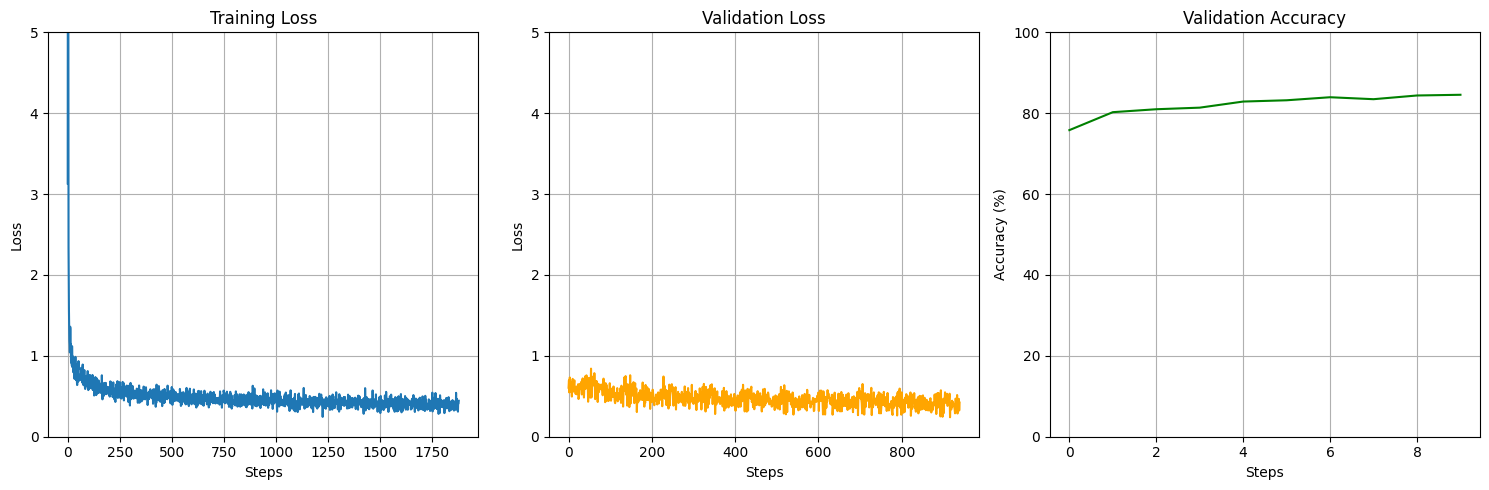

In [ ]:
plot_train_val_metrics(adagrad_train_losses, adagrad_val_losses, adagrad_val_accuracies, option=2, title='Adagrad with lr=1e-2, init_acc_sqr_grad=0,eps=1e-10', ymax = 5.0)

Let's compare our Adagrad loss to our SGD algorithms.

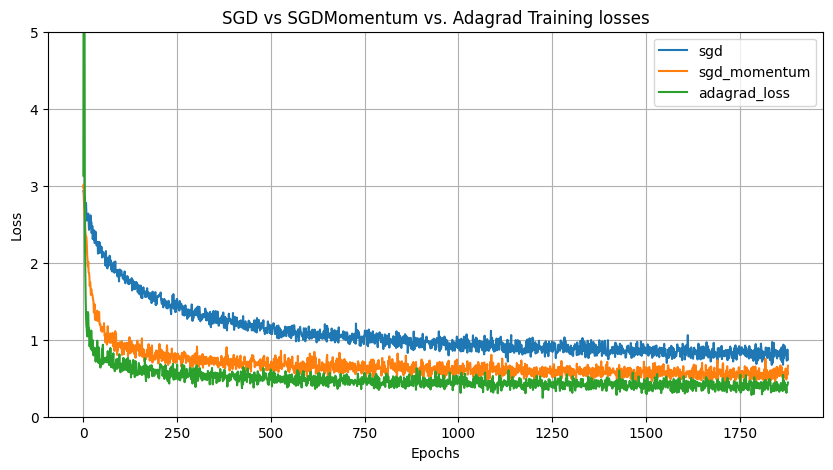

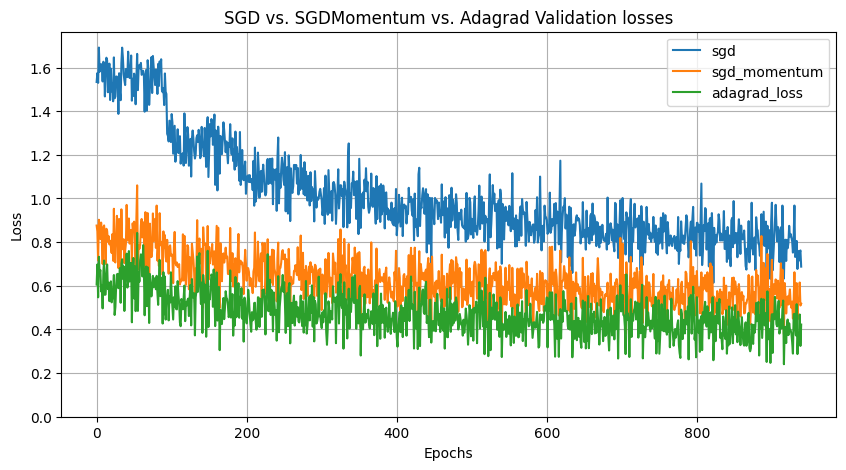

In [ ]:
train_losses.append(adagrad_train_losses)
val_losses.append(adagrad_val_losses)
labels = ['sgd', 'sgd_momentum', 'adagrad_loss']

plot_losses(train_losses, labels, 'SGD vs SGDMomentum vs. Adagrad Training losses', ymax=5.0)

plot_losses(val_losses, labels, 'SGD vs. SGDMomentum vs. Adagrad Validation losses')

Adagrad beats the other two pretty handily, but that initial spike in loss doesn't look very nice. Maybe if we get rid of that initial spike we can make Adagrad perform even better? Let's try some different initial values for $G$ and store them all in a `adagrad_losses` dictionary. Each key in the dictionary will be the initial $G$ value and the values of the dictionary will be a list of training loss per batch.

In [ ]:
ad_train_losses = {0: adagrad_train_losses}
ad_val_losses = {0: adagrad_val_losses}

In [ ]:
optimizer = Adagrad(model.parameters(), init_acc_sqr_grad=1.0)

In [ ]:
ad_train_losses[1.0],ad_val_losses[1.0],_ = train_and_evaluate(model, train_loader, val_loader, optimizer, criterion, device, n_epochs=10)

Training Epoch 1/10: 100%|██████████| 188/188 [00:09<00:00, 20.45it/s]


Epoch: 1 -> train_loss: 1.0385


Validation Epoch 1/10: 100%|██████████| 94/94 [00:02<00:00, 40.71it/s]


Epoch: 1 -> val_loss: 0.7892, val_acc: 70.47%


Training Epoch 2/10: 100%|██████████| 188/188 [00:09<00:00, 20.56it/s]


...

Epoch: 9 -> val_loss: 0.5579, val_acc: 79.20%


Training Epoch 10/10: 100%|██████████| 188/188 [00:09<00:00, 20.39it/s]


Epoch: 10 -> train_loss: 0.5567


Validation Epoch 10/10: 100%|██████████| 94/94 [00:02<00:00, 40.65it/s]

Epoch: 10 -> val_loss: 0.5653, val_acc: 78.88%


In [ ]:
optimizer = Adagrad(model.parameters(), init_acc_sqr_grad=0.1)

In [ ]:
ad_train_losses[0.1],ad_val_losses[0.1],_ = train_and_evaluate(model, train_loader, val_loader, optimizer, criterion, device, n_epochs=10)

Training Epoch 1/10: 100%|██████████| 188/188 [00:09<00:00, 20.35it/s]


Epoch: 1 -> train_loss: 0.8828


Validation Epoch 1/10: 100%|██████████| 94/94 [00:02<00:00, 41.04it/s]


Epoch: 1 -> val_loss: 0.7230, val_acc: 71.78%


Training Epoch 2/10: 100%|██████████| 188/188 [00:09<00:00, 20.21it/s]


...

Epoch: 9 -> val_loss: 0.4965, val_acc: 81.14%


Training Epoch 10/10: 100%|██████████| 188/188 [00:09<00:00, 20.48it/s]


Epoch: 10 -> train_loss: 0.4789


Validation Epoch 10/10: 100%|██████████| 94/94 [00:02<00:00, 41.06it/s]

Epoch: 10 -> val_loss: 0.4805, val_acc: 82.50%


In [ ]:
optimizer = Adagrad(model.parameters(), init_acc_sqr_grad=0.01)

In [ ]:
ad_train_losses[0.01],ad_val_losses[0.01],_ = train_and_evaluate(model, train_loader, val_loader, optimizer, criterion, device, n_epochs=10)

Training Epoch 1/10: 100%|██████████| 188/188 [00:09<00:00, 20.62it/s]


Epoch: 1 -> train_loss: 0.7879


Validation Epoch 1/10: 100%|██████████| 94/94 [00:02<00:00, 41.39it/s]


Epoch: 1 -> val_loss: 0.6974, val_acc: 73.57%


Training Epoch 2/10: 100%|██████████| 188/188 [00:09<00:00, 20.52it/s]


...

Epoch: 9 -> val_loss: 0.4562, val_acc: 83.12%


Training Epoch 10/10: 100%|██████████| 188/188 [00:09<00:00, 20.52it/s]


Epoch: 10 -> train_loss: 0.4352


Validation Epoch 10/10: 100%|██████████| 94/94 [00:02<00:00, 41.21it/s]

Epoch: 10 -> val_loss: 0.4474, val_acc: 83.27%


In [ ]:
optimizer = Adagrad(model.parameters(), init_acc_sqr_grad=0.001)

In [ ]:
ad_train_losses[0.001], ad_val_losses[0.01], _ = train_and_evaluate(model, train_loader, val_loader, optimizer, criterion, device, n_epochs=10)

Training Epoch 1/10: 100%|██████████| 188/188 [00:09<00:00, 20.49it/s]


Epoch: 1 -> train_loss: 0.8027


Validation Epoch 1/10: 100%|██████████| 94/94 [00:02<00:00, 41.10it/s]


Epoch: 1 -> val_loss: 0.6027, val_acc: 77.01%


Training Epoch 2/10: 100%|██████████| 188/188 [00:09<00:00, 20.52it/s]


...

Epoch: 9 -> val_loss: 0.4258, val_acc: 84.72%


Training Epoch 10/10: 100%|██████████| 188/188 [00:09<00:00, 20.57it/s]


Epoch: 10 -> train_loss: 0.4020


Validation Epoch 10/10: 100%|██████████| 94/94 [00:02<00:00, 41.24it/s]

Epoch: 10 -> val_loss: 0.4189, val_acc: 84.54%


Now let's compare all of our four values for the initial $G$ value.

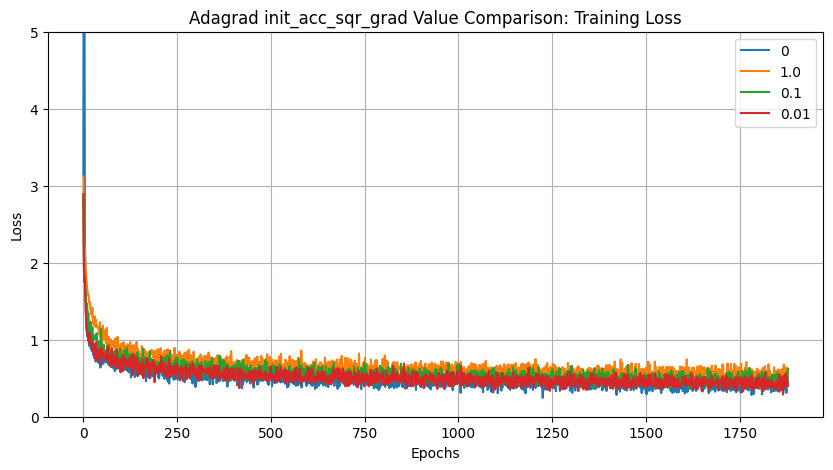

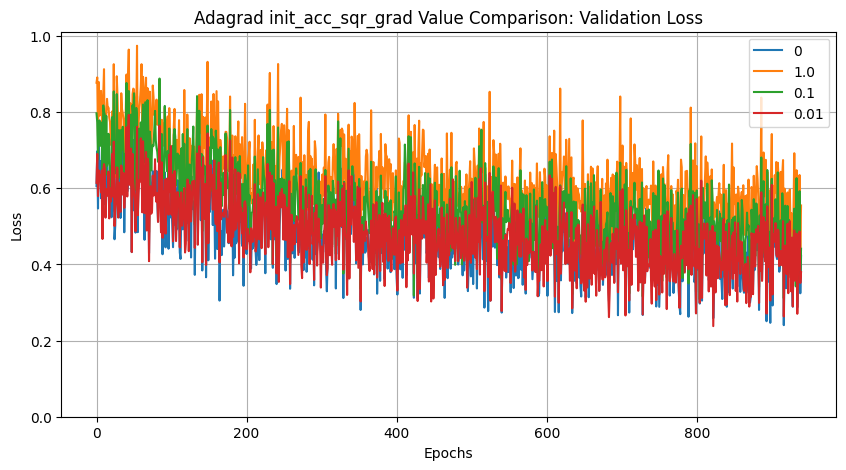

In [ ]:
labels, aggregate_train_losses = zip(*ad_train_losses.items())
labels, aggreagate_val_losses = zip(*ad_val_losses.items())

plot_losses(aggregate_train_losses, labels, 'Adagrad init_acc_sqr_grad Value Comparison: Training Loss', ymax=5.0)
plot_losses(aggreagate_val_losses, labels, 'Adagrad init_acc_sqr_grad Value Comparison: Validation Loss')

As we can see, performance of Adagrad increases as the initial $G$ value decreases, but decreasing $G$ also increases the initial spike in loss at the beginning of training.

Why does the performance decrease as the initial $G$ value increases? This is the major downside of Adagrad: as $G$ is monotonically increasing at each time-step it will be dividing the learning rate by a monotonically increasing number at each time-step. This causes the size of the steps taken to reduce every update step. As the results for an initial $G$ value of 1.0 show, we can see that these smaller step sizes actually increase the time taken for the model to converge, and in extreme cases will cause the step sizes to approach zero meaning the parameters will stop updating completely.

In practice, we do want the learning rate to decrease while training, but ideally would not want it to become zero.


## Optimizer 4: Adadelta

All of our update step equations can be written in the form of:

$$\theta_{t+1,i} = \theta_{t,i} + \Delta \theta_{t,i}$$

where $\Delta \theta_{t,i}$ is the size of the parameter update, i.e. in SGD we had:

$$\Delta \theta_{t,i} = - \eta \cdot \nabla_\theta J(\theta_{t,i})$$

and in Adagrad we had:

$$\Delta \theta_{t,i} = - \frac{\eta}{\sqrt{G_{t,i}}+\epsilon} \cdot \nabla_\theta J(\theta_{t,i}))$$

The problem of the Adagrad algorithm was that $G$ was monotonically increasing. Adadelta solves this problem by first taking the Adagrad algorithm and replacing $G_{t,i}$ with $E[g^2]_{t,i}$, an exponential moving average of the square of the gradients so far.

$$E[g^2]_{t,i} = \rho E[g^2]_{t-1,i} + (1-\rho)g^2_{t,i}$$

where $g_{t,i} = \nabla_\theta J(\theta_{t,i})$, which we've done just to simplify the notation, and $\rho$ controls how much we care about the previous gradients in the exponential moving average, $\rho=0$ means we don't care about them at all.

This means our update step equation is:

$$\Delta \theta_t = - \frac{\eta}{\sqrt{E[g^2]_{t,i} + \epsilon}} \cdot g_{t,i}$$

Notice that the $\epsilon$ term has now moved inside the square root, which we're copying from PyTorch.

The problem with the above equation, and in fact all update equations seen so far, is the units of the update do not match the units of the parameters. The updates have units of $\frac{\delta J}{\delta \theta}$, which simplify to $\frac{1}{\text{units of }\theta}$ if we assume the cost function is unitless. However, we want our update equations to have units of $\theta$.

To solve this the Adadelta equation uses a second exponential moving average, but this one is of the parameter updates.

To get the final Adadelta equation, we take our first attempt, but replace $\eta$ with an exponential moving average of the squared parameter updates:

$$E[\Delta \theta^2]_{t-1,i} = \rho E[\Delta \theta^2]_{t-2,i} + (1-\rho)\Delta \theta^2_{t-1,i}$$

Thus, we get:

$$\Delta \theta_{t,i} = - \frac{\sqrt{E[\Delta \theta^2]_{t-1,i} + \epsilon}}{\sqrt{E[g^2]_{t,i}+\epsilon}} \cdot g_{t,i}$$

The units now "match" as we now have units of $\frac{\theta^2}{\theta} = \theta$.

This means that we do not even need to use a learning rate value, however in the PyTorch implementation they do use one (which defaults to 1.0), so they end up with:

$$\Delta \theta_{t,i} = - \eta \cdot \frac{\sqrt{E[\Delta \theta^2]_{t-1,i} + \epsilon}}{\sqrt{E[g^2]_{t,i}+\epsilon}} \cdot g_{t,i}$$

Thus:

$$\theta_{t+1,i} = \theta_{t,i} - \eta \cdot \frac{\sqrt{E[\Delta \theta^2]_{t-1,i} + \epsilon}}{\sqrt{E[g^2]_{t,i}+\epsilon}} \cdot g_{t,i}$$

PyTorch also changes default `eps` value from what it was in Adagrad, from `1e-10` to `1e-6`.

In [ ]:
class Adadelta:
    def __init__(self, model_params, lr=1.0, rho=0.9, eps=1e-6):
        self.model_params = list(model_params)
        self.lr = lr
        self.rho = rho
        self.eps = eps
        self.avg_sqr_grads = [torch.zeros_like(p) for p in self.model_params]
        self.avg_sqr_deltas = [torch.zeros_like(p) for p in self.model_params]

    def zero_grad(self):
        for param in self.model_params:
            param.grad = None

    @torch.no_grad()
    def step(self):
        for param, avg_sqr_grad, avg_sqr_delta in zip(self.model_params, \
                                                      self.avg_sqr_grads, \
                                                      self.avg_sqr_deltas):
            avg_sqr_grad.mul_(self.rho).add_(param.grad * param.grad * (1 - self.rho))
            std = avg_sqr_grad.add(self.eps).sqrt()
            delta = avg_sqr_delta.add(self.eps).sqrt().div(std).mul(param.grad)
            param.sub_(self.lr * delta)
            avg_sqr_delta.mul_(self.rho).add_(delta * delta * (1 - self.rho))

In [ ]:
optimizer = Adadelta(model.parameters())

In [ ]:
adadelta_train_losses, adadelta_val_losses, adadelta_val_accuracies = train_and_evaluate(model, train_loader, val_loader, optimizer, criterion, device, n_epochs=10)

Training Epoch 1/10: 100%|██████████| 188/188 [00:09<00:00, 20.31it/s]


Epoch: 1 -> train_loss: 0.8281


Validation Epoch 1/10: 100%|██████████| 94/94 [00:02<00:00, 41.12it/s]


Epoch: 1 -> val_loss: 0.6773, val_acc: 73.28%


Training Epoch 2/10: 100%|██████████| 188/188 [00:09<00:00, 20.39it/s]


...

Epoch: 9 -> val_loss: 0.4307, val_acc: 83.79%


Training Epoch 10/10: 100%|██████████| 188/188 [00:09<00:00, 20.35it/s]


Epoch: 10 -> train_loss: 0.4009


Validation Epoch 10/10: 100%|██████████| 94/94 [00:02<00:00, 41.07it/s]

Epoch: 10 -> val_loss: 0.4262, val_acc: 83.91%


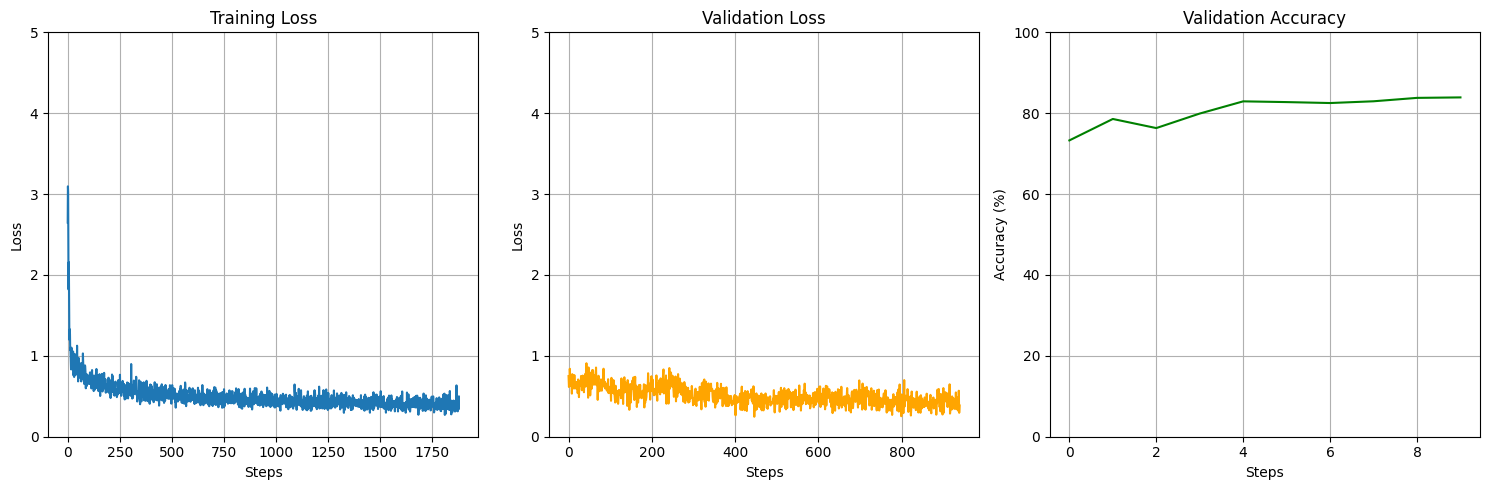

In [ ]:
plot_train_val_metrics(adadelta_train_losses, adadelta_val_losses, adadelta_val_accuracies, option=2, title='Adadelta with lr=1.0, rho=0.9, eps=1e-6', ymax = 5.0)


We can see that we avoid the large initial spike in loss due to the numerator term (the exponential moving average of parameter updates) starting out very small.

Let's compare Adadelta to all the other algorithms so far.

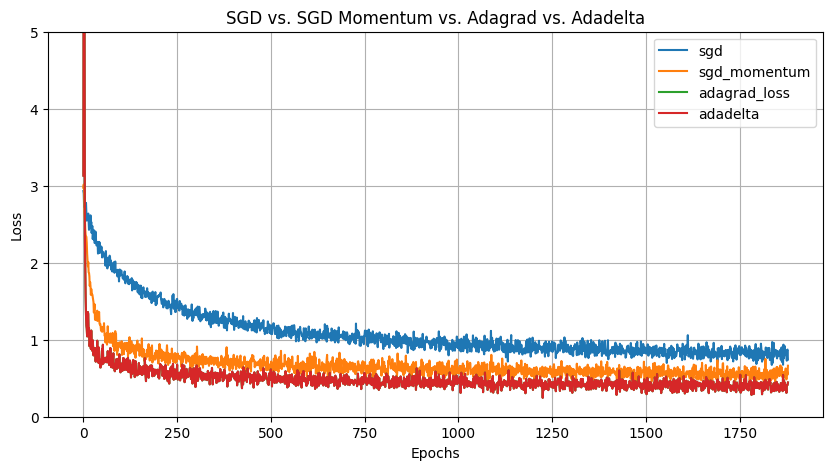

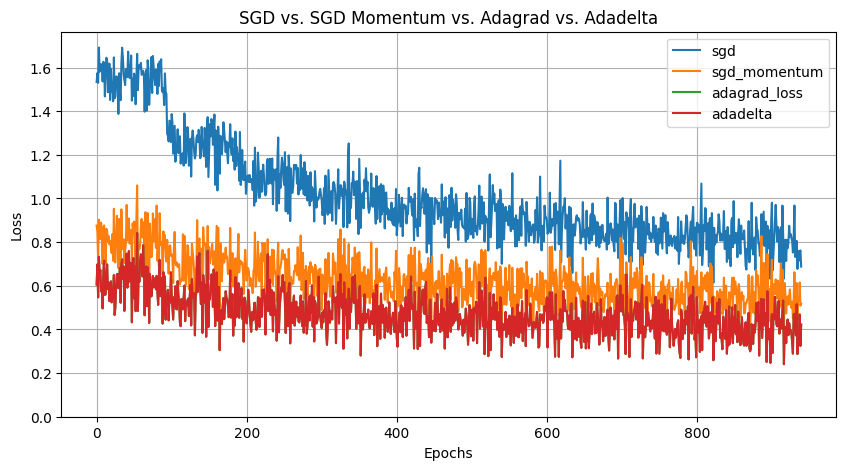

In [ ]:
train_losses.append(adadelta_train_losses)
val_losses.append(adadelta_val_losses)
labels = ['sgd', 'sgd_momentum', 'adagrad_loss','adadelta']

plot_losses(train_losses, labels, 'SGD vs. SGD Momentum vs. Adagrad vs. Adadelta', ymax=5.0)
plot_losses(val_losses, labels, 'SGD vs. SGD Momentum vs. Adagrad vs. Adadelta')

We can see that Adagrad and Adadelta have pretty much equal performance, but Adadelta doesn't have the large initial spike in loss.

## Optimizer 5: RMSprop

Remember that "first attempt" at the Adadelta equation? The one that we said had the issue of the update units not matching the parameter units? Turns out you can completely ignore the fact that these units don't match up and this gives you the RMSprop algorithm!

$$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{E[g^2]_{t,i} + \epsilon}} \cdot g_{t,i}$$

In PyTorch, they move the $\epsilon$ term back outside of the square root, similar to Adagrad. This gives us:

$$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{E[g^2]_{t,i}} + \epsilon} \cdot g_{t,i}$$

In the PyTorch implementation they also change the default learning rate to `1e-2`, rename `rho` to `alpha` whilst giving it a new default value of `0.99`, and also change the default `eps` to `1e-8`.

In [ ]:
class RMSprop:
    def __init__(self, model_params, lr=1e-2, alpha=0.99, eps=1e-8):
        self.model_params = list(model_params)
        self.lr = lr
        self.alpha = alpha
        self.eps = eps
        self.avg_sqr_grads = [torch.zeros_like(p) for p in self.model_params]

    def zero_grad(self):
        for param in self.model_params:
            param.grad = None

    @torch.no_grad()
    def step(self):
        for param, avg_sqr_grad in zip(self.model_params, self.avg_sqr_grads):
            avg_sqr_grad.mul_(self.alpha).add_(param.grad * param.grad * (1 - self.alpha))
            std = avg_sqr_grad.sqrt().add(self.eps)
            param.sub_((self.lr / std) * param.grad)

In [ ]:
optimizer = RMSprop(model.parameters())

In [ ]:
rmsprop_train_losses, rmsprop_val_losses, rmsprop_val_accuracies = train_and_evaluate(model, train_loader, val_loader, optimizer, criterion, device, n_epochs=10)


Training Epoch 1/10: 100%|██████████| 188/188 [00:09<00:00, 20.47it/s]


Epoch: 1 -> train_loss: 42.4103


Validation Epoch 1/10: 100%|██████████| 94/94 [00:02<00:00, 41.04it/s]


Epoch: 1 -> val_loss: 0.7814, val_acc: 69.67%


Training Epoch 2/10: 100%|██████████| 188/188 [00:09<00:00, 20.47it/s]


...

Epoch: 9 -> val_loss: 0.5836, val_acc: 77.38%


Training Epoch 10/10: 100%|██████████| 188/188 [00:09<00:00, 20.59it/s]


Epoch: 10 -> train_loss: 0.5515


Validation Epoch 10/10: 100%|██████████| 94/94 [00:02<00:00, 41.43it/s]

Epoch: 10 -> val_loss: 0.6400, val_acc: 73.11%


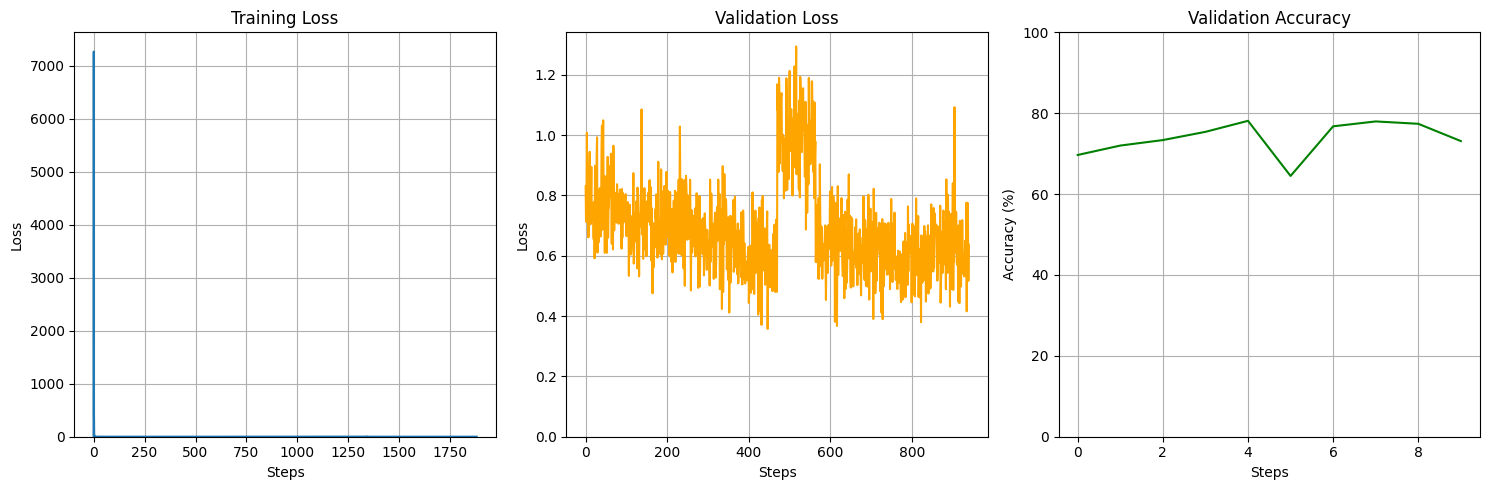

In [ ]:

# Plot the results for RMSprop
plot_train_val_metrics(rmsprop_train_losses, rmsprop_val_losses, rmsprop_val_accuracies, option=2, title='RMSprop with lr=0.01, alpha=0.99, eps=1e-8')

We run into a similar issue as we did with Adagrad, the small denominator in the initial time-steps lead to large step sizes which give huge spikes in loss values during the early stages of training.

Let's zoom in to the interesting bit to get a better view of what's going on.

In [ ]:
plot_train_val_metrics(rmsprop_train_losses, rmsprop_val_losses, rmsprop_val_accuracies, option=2, title='RMSprop with lr=0.01, alpha=0.99, eps=1e-8', ymax=5.0)

One thing to note is that the PyTorch implementation of RMSprop differs from the TensorFlow implementation in two main ways. In TensorFlow the $\epsilon$ term is inside the square root, as it is in the initial RMSprop algorithm, and the exponential moving average of the squared gradients is initialized to ones instead of zeros.

This TensorFlow variant is [apparently more stable](https://github.com/pytorch/pytorch/issues/23796) than the PyTorch version, so we'll implement it here and see if it provides any noticeable improvement.

In [ ]:
class RMSpropAlt:
    def __init__(self, model_params, lr=1e-2, alpha=0.99, eps=1e-8):
        self.model_params = list(model_params)
        self.lr = lr
        self.alpha = alpha
        self.eps = eps
        self.avg_sqr_grads = [torch.ones_like(p) for p in self.model_params]

    def zero_grad(self):
        for param in self.model_params:
            param.grad = None

    @torch.no_grad()
    def step(self):
        for param, avg_sqr_grad in zip(self.model_params, self.avg_sqr_grads):
            avg_sqr_grad.mul_(self.alpha).add_(param.grad * param.grad * (1 - self.alpha))
            std = avg_sqr_grad.add(self.eps).sqrt()
            param.sub_((self.lr / std) * param.grad)

In [ ]:
optimizer = RMSpropAlt(model.parameters())
rmspropalt_train_losses, rmspropalt_val_losses, rmspropalt_val_accuracies = train_and_evaluate(model, train_loader, val_loader, optimizer, criterion, device, n_epochs=10)


Training Epoch 1/10: 100%|██████████| 188/188 [00:09<00:00, 20.65it/s]


Epoch: 1 -> train_loss: 1.0452


Validation Epoch 1/10: 100%|██████████| 94/94 [00:02<00:00, 41.38it/s]


Epoch: 1 -> val_loss: 0.8513, val_acc: 66.91%


Training Epoch 2/10: 100%|██████████| 188/188 [00:09<00:00, 20.60it/s]


...

Epoch: 9 -> val_loss: 0.6492, val_acc: 76.21%


Training Epoch 10/10: 100%|██████████| 188/188 [00:09<00:00, 20.60it/s]


Epoch: 10 -> train_loss: 0.6340


Validation Epoch 10/10: 100%|██████████| 94/94 [00:02<00:00, 41.51it/s]

Epoch: 10 -> val_loss: 0.5803, val_acc: 78.78%


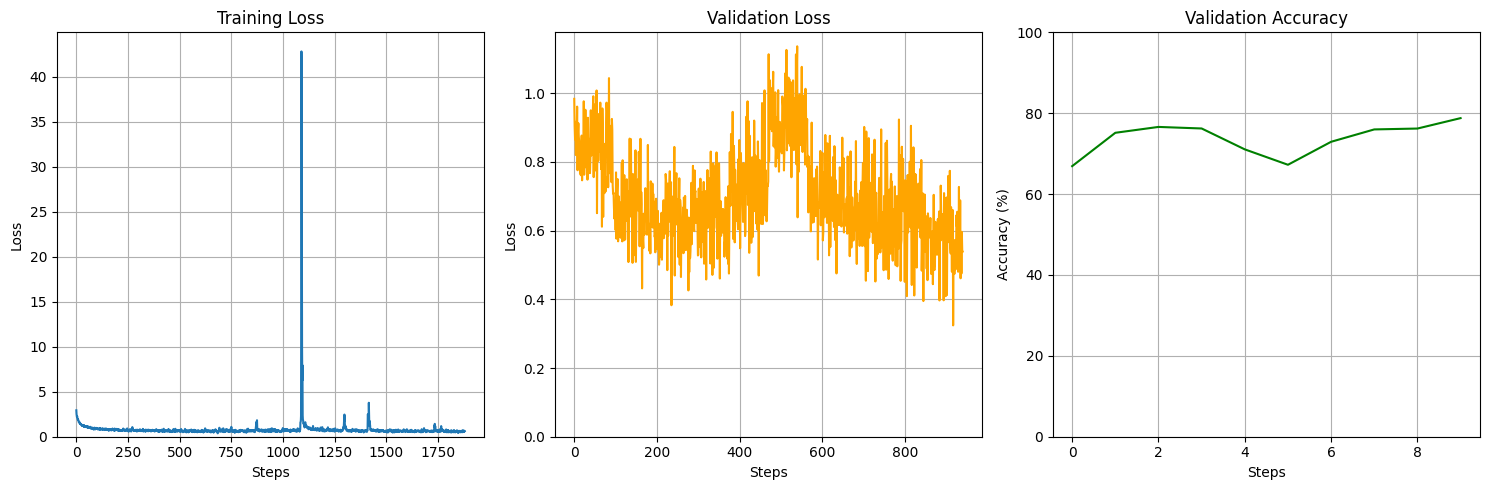

In [ ]:
plot_train_val_metrics(rmspropalt_train_losses, rmspropalt_val_losses, rmspropalt_val_accuracies, option=2, title='RMSpropAlt with lr=0.01, alpha=0.99, eps=1e-8')

The TensorFlow variant doesn't have the large initial spikes in loss, but it actually looks **less** stable than the PyTorch RMSprop implementation, even when ignoring the large spikes during training.

Let's compare the two.

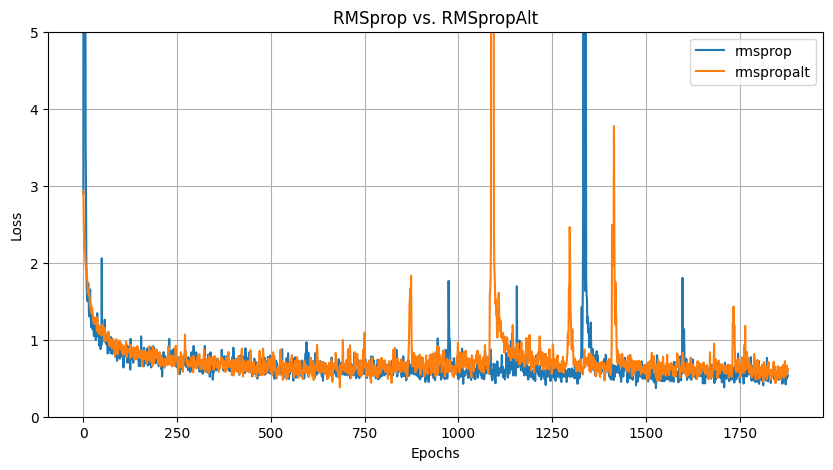

In [ ]:
rms_losses = [rmsprop_train_losses, rmspropalt_train_losses]
labels = ['rmsprop', 'rmspropalt']

plot_losses(rms_losses, labels, 'RMSprop vs. RMSpropAlt', ymax=5.0)

The TensorFlow variant seems less stable. However, this is an experiment with a sample size of one, so we can't make any general claims about these two RMSprop versions.

Let's do a quick comparison of these two against Adagrad and Adadelta:

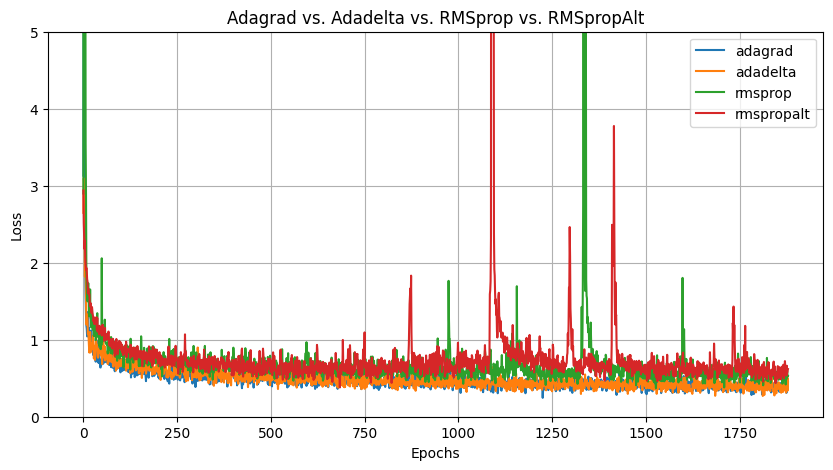

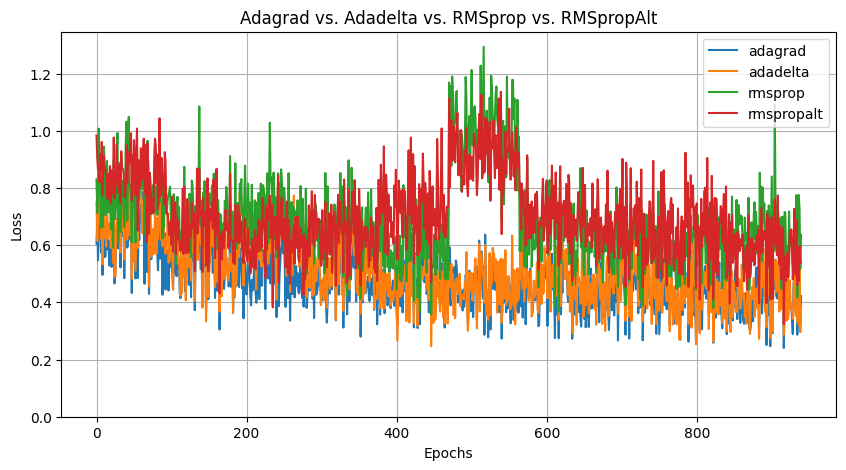

In [ ]:
train_losses = [adagrad_train_losses, adadelta_train_losses, rmsprop_train_losses, rmspropalt_train_losses]
labels= ['adagrad', 'adadelta','rmsprop', 'rmspropalt']
val_losses = [adagrad_val_losses, adadelta_val_losses,rmsprop_val_losses, rmspropalt_val_losses]


plot_losses(train_losses, labels, 'Adagrad vs. Adadelta vs. RMSprop vs. RMSpropAlt', ymax=5.0)
plot_losses(val_losses, labels, 'Adagrad vs. Adadelta vs. RMSprop vs. RMSpropAlt')

We can see that both RMSprop variants aren't as good as Adagrad or Adadelta.

RMSprop is commonly used in reinforcement learning and one hyperparameter that's tweaked a lot is the `eps` parameter. Let's try a few values and see if they make any difference in our experimental set-up.

In [ ]:
rmsprop_losses = {1e-8: rmsprop_train_losses}

In [ ]:
optimizer = RMSprop(model.parameters(), eps=1e-6)

In [ ]:
rmsprop_losses[1e-6],_,_ = train_and_evaluate(model, train_loader, val_loader, optimizer, criterion, device, n_epochs=10)


Training Epoch 1/10: 100%|██████████| 188/188 [00:09<00:00, 20.60it/s]


Epoch: 1 -> train_loss: 23.8664


Validation Epoch 1/10: 100%|██████████| 94/94 [00:02<00:00, 41.47it/s]


Epoch: 1 -> val_loss: 0.9123, val_acc: 65.84%


Training Epoch 2/10: 100%|██████████| 188/188 [00:09<00:00, 20.59it/s]


...

Epoch: 9 -> val_loss: 0.7013, val_acc: 76.90%


Training Epoch 10/10: 100%|██████████| 188/188 [00:09<00:00, 20.61it/s]


Epoch: 10 -> train_loss: 0.6157


Validation Epoch 10/10: 100%|██████████| 94/94 [00:02<00:00, 41.52it/s]

Epoch: 10 -> val_loss: 0.7243, val_acc: 73.95%


In [ ]:
optimizer = RMSprop(model.parameters(), eps=1e-4)

In [ ]:
rmsprop_losses[1e-4],_,_ = train_and_evaluate(model, train_loader, val_loader, optimizer, criterion, device, n_epochs=10)


Training Epoch 1/10: 100%|██████████| 188/188 [00:09<00:00, 20.47it/s]


Epoch: 1 -> train_loss: 25.2289


Validation Epoch 1/10: 100%|██████████| 94/94 [00:02<00:00, 41.18it/s]


Epoch: 1 -> val_loss: 0.8020, val_acc: 68.13%


Training Epoch 2/10: 100%|██████████| 188/188 [00:09<00:00, 20.48it/s]


...

Epoch: 9 -> val_loss: 0.5867, val_acc: 78.94%


Training Epoch 10/10: 100%|██████████| 188/188 [00:09<00:00, 20.48it/s]


Epoch: 10 -> train_loss: 0.5221


Validation Epoch 10/10: 100%|██████████| 94/94 [00:02<00:00, 41.14it/s]

Epoch: 10 -> val_loss: 0.5946, val_acc: 78.97%


In [ ]:
optimizer = RMSprop(model.parameters(), eps=1e-2)

In [ ]:
rmsprop_losses[1e-2],_,_ = train_and_evaluate(model, train_loader, val_loader, optimizer, criterion, device, n_epochs=10)


Training Epoch 1/10: 100%|██████████| 188/188 [00:09<00:00, 20.59it/s]


Epoch: 1 -> train_loss: 1.3815


Validation Epoch 1/10: 100%|██████████| 94/94 [00:02<00:00, 41.48it/s]


Epoch: 1 -> val_loss: 0.6732, val_acc: 72.83%


Training Epoch 2/10: 100%|██████████| 188/188 [00:09<00:00, 20.60it/s]


...

Epoch: 9 -> val_loss: 0.4637, val_acc: 82.92%


Training Epoch 10/10: 100%|██████████| 188/188 [00:09<00:00, 20.49it/s]


Epoch: 10 -> train_loss: 0.4334


Validation Epoch 10/10: 100%|██████████| 94/94 [00:02<00:00, 41.27it/s]

Epoch: 10 -> val_loss: 0.4478, val_acc: 83.72%


In [ ]:
optimizer = RMSprop(model.parameters(), eps=1)

In [ ]:
rmsprop_losses[1],_,_ = train_and_evaluate(model, train_loader, val_loader, optimizer, criterion, device, n_epochs=10)


Training Epoch 1/10: 100%|██████████| 188/188 [00:09<00:00, 20.44it/s]


Epoch: 1 -> train_loss: 1.0791


Validation Epoch 1/10: 100%|██████████| 94/94 [00:02<00:00, 41.17it/s]


Epoch: 1 -> val_loss: 0.8118, val_acc: 69.76%


Training Epoch 2/10: 100%|██████████| 188/188 [00:09<00:00, 20.47it/s]


...

Epoch: 9 -> val_loss: 0.5593, val_acc: 78.93%


Training Epoch 10/10: 100%|██████████| 188/188 [00:09<00:00, 20.47it/s]


Epoch: 10 -> train_loss: 0.5529


Validation Epoch 10/10: 100%|██████████| 94/94 [00:02<00:00, 41.19it/s]

Epoch: 10 -> val_loss: 0.5581, val_acc: 79.10%


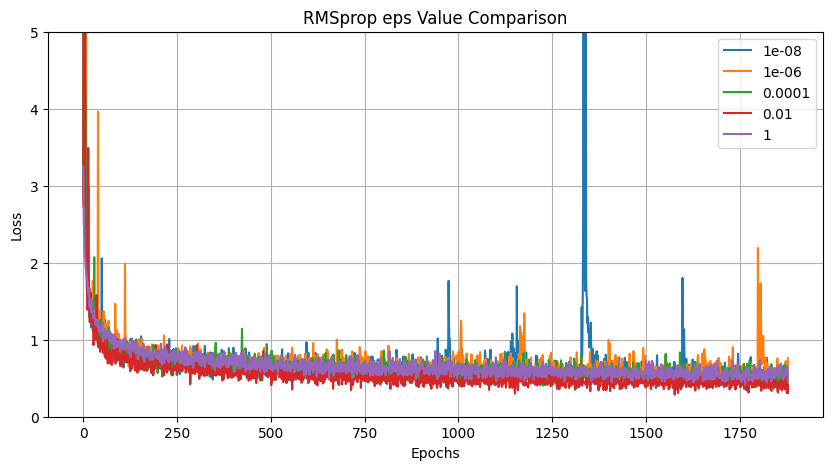

In [ ]:
labels, rms_losses = zip(*rmsprop_losses.items())

plot_losses(rms_losses, labels, 'RMSprop eps Value Comparison', ymax=5.0)

Increasing `eps` improves performance to a point, `eps=1e-2` gives the best performance, and then performance starts degrading, `eps=1` gives the worst performance.

Let's try the same thing with the TensorFlow variant of RMSprop.

In [ ]:
rmspropalt_losses = {1e-8: rmspropalt_train_losses}

In [ ]:
optimizer = RMSpropAlt(model.parameters(), eps=1e-6)

In [ ]:
rmspropalt_losses[1e-6] ,_,_ = train_and_evaluate(model, train_loader, val_loader, optimizer, criterion, device, n_epochs=10)

Training Epoch 1/10: 100%|██████████| 188/188 [00:09<00:00, 20.43it/s]


Epoch: 1 -> train_loss: 1.0475


Validation Epoch 1/10: 100%|██████████| 94/94 [00:02<00:00, 41.20it/s]


Epoch: 1 -> val_loss: 0.7690, val_acc: 70.38%


Training Epoch 2/10: 100%|██████████| 188/188 [00:09<00:00, 20.48it/s]


...

Epoch: 9 -> val_loss: 0.6025, val_acc: 77.59%


Training Epoch 10/10: 100%|██████████| 188/188 [00:09<00:00, 20.47it/s]


Epoch: 10 -> train_loss: 0.5632


Validation Epoch 10/10: 100%|██████████| 94/94 [00:02<00:00, 41.31it/s]

Epoch: 10 -> val_loss: 0.6060, val_acc: 76.70%


In [ ]:
optimizer = RMSpropAlt(model.parameters(), eps=1e-4)

In [ ]:
rmspropalt_losses[1e-4] ,_,_ = train_and_evaluate(model, train_loader, val_loader, optimizer, criterion, device, n_epochs=10)

Training Epoch 1/10: 100%|██████████| 188/188 [00:09<00:00, 20.43it/s]


Epoch: 1 -> train_loss: 1.0346


Validation Epoch 1/10: 100%|██████████| 94/94 [00:02<00:00, 41.20it/s]


Epoch: 1 -> val_loss: 0.7629, val_acc: 71.07%


Training Epoch 2/10: 100%|██████████| 188/188 [00:09<00:00, 20.46it/s]


...

Epoch: 9 -> val_loss: 0.5414, val_acc: 80.11%


Training Epoch 10/10: 100%|██████████| 188/188 [00:09<00:00, 20.49it/s]


Epoch: 10 -> train_loss: 0.4516


Validation Epoch 10/10: 100%|██████████| 94/94 [00:02<00:00, 41.28it/s]

Epoch: 10 -> val_loss: 0.4819, val_acc: 81.54%


In [ ]:
optimizer = RMSpropAlt(model.parameters(), eps=1e-2)

In [ ]:
rmspropalt_losses[1e-2] ,_,_ = train_and_evaluate(model, train_loader, val_loader, optimizer, criterion, device, n_epochs=10)

Training Epoch 1/10: 100%|██████████| 188/188 [00:09<00:00, 20.56it/s]


Epoch: 1 -> train_loss: 1.0570


Validation Epoch 1/10: 100%|██████████| 94/94 [00:02<00:00, 41.29it/s]


Epoch: 1 -> val_loss: 0.8285, val_acc: 70.02%


Training Epoch 2/10: 100%|██████████| 188/188 [00:09<00:00, 20.62it/s]


...

Epoch: 9 -> val_loss: 0.4504, val_acc: 83.60%


Training Epoch 10/10: 100%|██████████| 188/188 [00:09<00:00, 20.38it/s]


Epoch: 10 -> train_loss: 0.4408


Validation Epoch 10/10: 100%|██████████| 94/94 [00:02<00:00, 41.07it/s]

Epoch: 10 -> val_loss: 0.4736, val_acc: 82.43%


In [ ]:
optimizer = RMSpropAlt(model.parameters(), eps=1)

In [ ]:
rmspropalt_losses[1] ,_,_ = train_and_evaluate(model, train_loader, val_loader, optimizer, criterion, device, n_epochs=10)

Training Epoch 1/10: 100%|██████████| 188/188 [00:09<00:00, 20.35it/s]


Epoch: 1 -> train_loss: 1.1689


Validation Epoch 1/10: 100%|██████████| 94/94 [00:02<00:00, 40.98it/s]


Epoch: 1 -> val_loss: 0.8599, val_acc: 67.66%


Training Epoch 2/10: 100%|██████████| 188/188 [00:09<00:00, 20.38it/s]


...

Epoch: 9 -> val_loss: 0.5754, val_acc: 78.34%


Training Epoch 10/10: 100%|██████████| 188/188 [00:09<00:00, 20.49it/s]


Epoch: 10 -> train_loss: 0.5560


Validation Epoch 10/10: 100%|██████████| 94/94 [00:02<00:00, 41.17it/s]

Epoch: 10 -> val_loss: 0.5592, val_acc: 79.54%


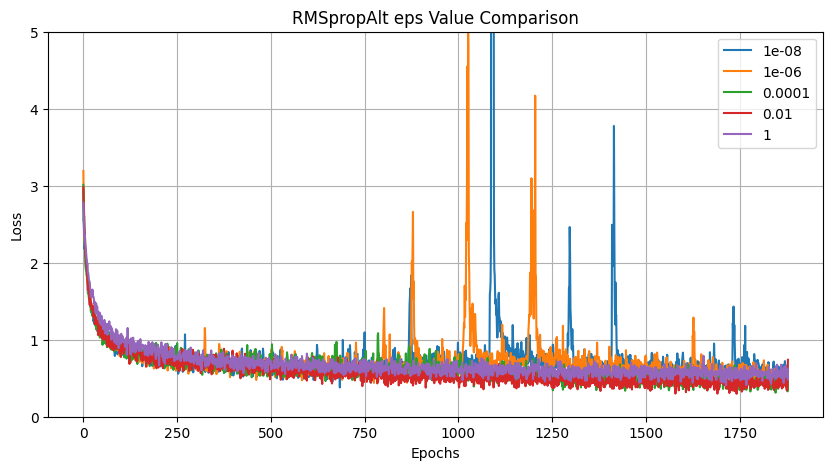

In [ ]:
labels, rmsalt_losses = zip(*rmspropalt_losses.items())

plot_losses(rmsalt_losses, labels, 'RMSpropAlt eps Value Comparison', ymax=5.0)

We get a similar thing happening here, it looks like the best `eps` value is also around `1e-2`.

Let's compare the two RMSprop variants with an `eps=1e-2`.

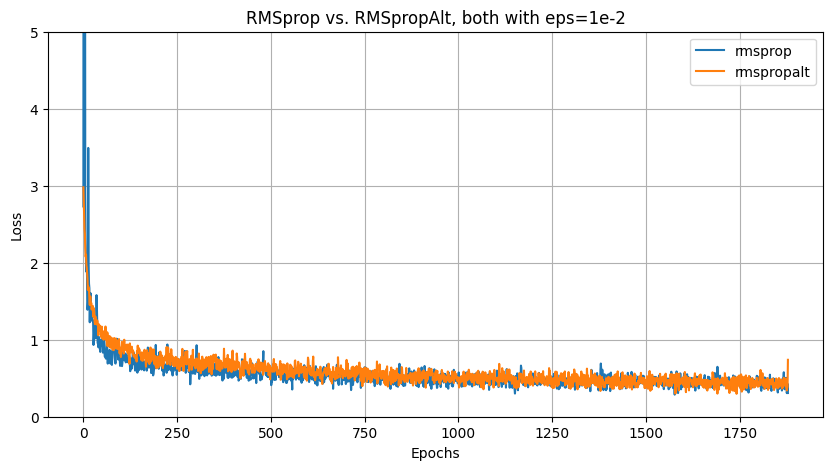

In [ ]:
rms_compare_losses = [rmsprop_losses[1e-2], rmspropalt_losses[1e-2]]
labels = ['rmsprop', 'rmspropalt']

plot_losses(rms_compare_losses, labels, 'RMSprop vs. RMSpropAlt, both with eps=1e-2', ymax=5.0)

Looks like the PyTorch variant of RMSprop is still better (converges to the minimum loss faster), so now let's compare it against Adagrad and Adadelta again.

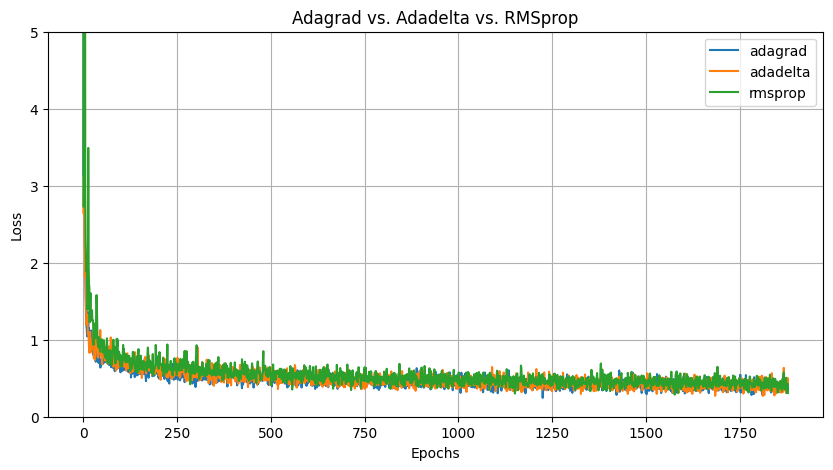

In [ ]:
compare_losses = [adagrad_train_losses, adadelta_train_losses, rmsprop_losses[1e-2]]
labels = ['adagrad', 'adadelta', 'rmsprop']

plot_losses(compare_losses, labels, 'Adagrad vs. Adadelta vs. RMSprop', ymax=5.0)

They're all very close, maybe RMSprop is slightly worse?

Let's zoom in.

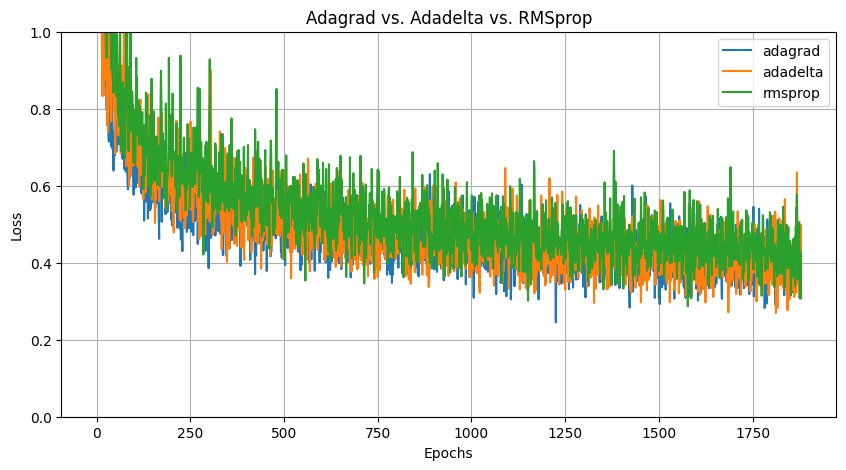

In [ ]:

plot_losses(compare_losses, labels, 'Adagrad vs. Adadelta vs. RMSprop', ymax=1.0)

It's still a bit hard to tell.

How about we smooth the loss curves with a moving average?

In [ ]:
def moving_average(x, w=5):
    return np.convolve(x, np.ones(w), 'valid') / w

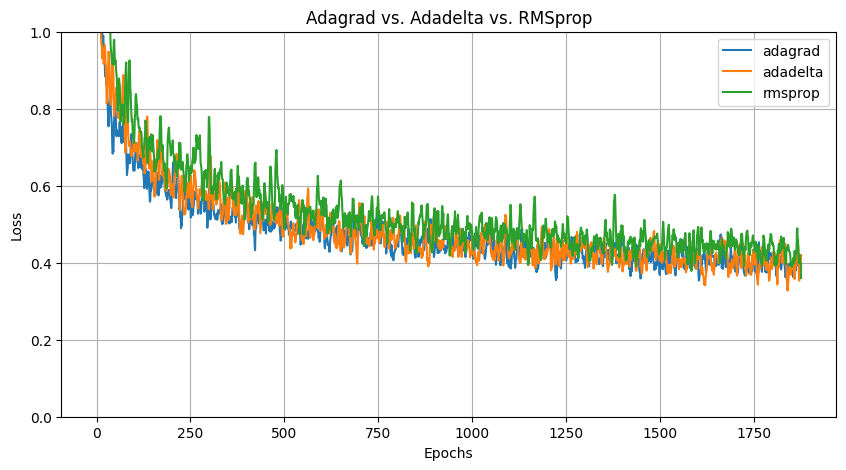

In [ ]:

smoothed_losses = [moving_average(loss) for loss in compare_losses]
labels = ['adagrad', 'adadelta', 'rmsprop']

plot_losses(smoothed_losses, labels, 'Adagrad vs. Adadelta vs. RMSprop', ymax=1.0)

RMSprop is looks like it's the worst of the three, but not really by a lot.

Before we ruin our eyes by squinting at loss curves for hours, let's move on to the final optimization algorithm: Adam.

## Optimizer 6: Adam

RMSprop's idea of annealing the step size over time, whilst using an exponential moving average to avoid saturation, seemed to work out OK. What if we added momentum to it? That's how you get Adam.

Adam has an exponential moving average of the gradients, like the momentum term that can be added to SGD, and an exponential moving average of squared gradients, like RMSprop and Adadelta.

$$\theta_{t+1} = \theta_t - \eta \cdot \frac{m_{t,i}}{\sqrt{v_{t,i}}+\epsilon}$$

where:

\begin{align*}
    m_{t,i} &= \beta_1 m_{t-1,i} + (1-\beta_1)g_{t,i} \\
    v_{t,i} &= \beta_2 v_{t-1,i} + (1-\beta_2)g_{t,i}^2
\end{align*}

Adam's $m_{t,i}$ is equal to $v_{t,i}$ from SGD with momentum if it had a $(1-\gamma)$ term. Adam's $v_{t,i} = E[g^2]_{t,i}$ from RMSprop and Adadelta, with $\rho$ replaced by $\beta_2$.

As $m$ and $v$ are initialized to zero and $\beta_1$ and $\beta_2$ are initialized close to one the $m$ and $v$ values calculated on the first few update steps are "biased" towards very small values. This is why we saw a huge loss for the first steps of Adagrad, Adadelta and RMSprop.

To solve this, Adam uses "bias corrected" values of $m$ and $v$, calculated as:

\begin{align*}
    \widehat{m}_{t,i} &= \frac{m_{t,i}}{1-\beta_1^t} \\
    \widehat{v}_{t,i} &= \frac{v_{t,i}}{1-\beta_2^t}
\end{align*}

This gives the final Adam equation as:

$$\theta_{t+1} = \theta_t - \eta \cdot \frac{\widehat{m}_{t,i}}{\sqrt{\widehat{v}_{t,i}}+\epsilon}$$

Note that the bias corrected values on the first call to `step` are calculated with $t = 1$ and not $t = 0$.

In [ ]:
class Adam:
    def __init__(self, model_params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8):
        self.model_params = list(model_params)
        self.lr = lr
        self.beta_1, self.beta_2 = betas
        self.eps = eps
        self.avg_grads = [torch.zeros_like(p) for p in self.model_params]
        self.avg_sqr_grads = [torch.zeros_like(p) for p in self.model_params]
        self.n_steps = 0

    def zero_grad(self):
        for param in self.model_params:
            param.grad = None

    @torch.no_grad()
    def step(self):
        for param, avg_grad, avg_sqr_grad in zip(self.model_params, \
                                                 self.avg_grads, \
                                                 self.avg_sqr_grads):
            self.n_steps += 1
            avg_grad.mul_(self.beta_1).add_(param.grad * (1 - self.beta_1))
            avg_sqr_grad.mul_(self.beta_2).add_(param.grad * param.grad * (1 - self.beta_2))
            avg_grad_corrected = avg_grad.div(1 - self.beta_1 ** self.n_steps)
            avg_sqr_grad_corrected = avg_sqr_grad.div(1 - self.beta_2 ** self.n_steps)
            std = avg_sqr_grad_corrected.sqrt().add(self.eps)
            param.sub_(self.lr * avg_grad_corrected / std)

In [ ]:
optimizer = Adam(model.parameters())

In [ ]:
adam_train_losses, adam_val_losses, adam_val_accuracies = train_and_evaluate(model, train_loader, val_loader, optimizer, criterion, device, n_epochs=10)


Training Epoch 1/10: 100%|██████████| 188/188 [00:09<00:00, 20.28it/s]


Epoch: 1 -> train_loss: 0.7073


Validation Epoch 1/10: 100%|██████████| 94/94 [00:02<00:00, 40.97it/s]


Epoch: 1 -> val_loss: 0.5922, val_acc: 78.19%


Training Epoch 2/10: 100%|██████████| 188/188 [00:09<00:00, 20.31it/s]


...

Epoch: 9 -> val_loss: 0.3931, val_acc: 85.12%


Training Epoch 10/10: 100%|██████████| 188/188 [00:09<00:00, 20.44it/s]


Epoch: 10 -> train_loss: 0.3777


Validation Epoch 10/10: 100%|██████████| 94/94 [00:02<00:00, 41.16it/s]

Epoch: 10 -> val_loss: 0.4064, val_acc: 85.17%


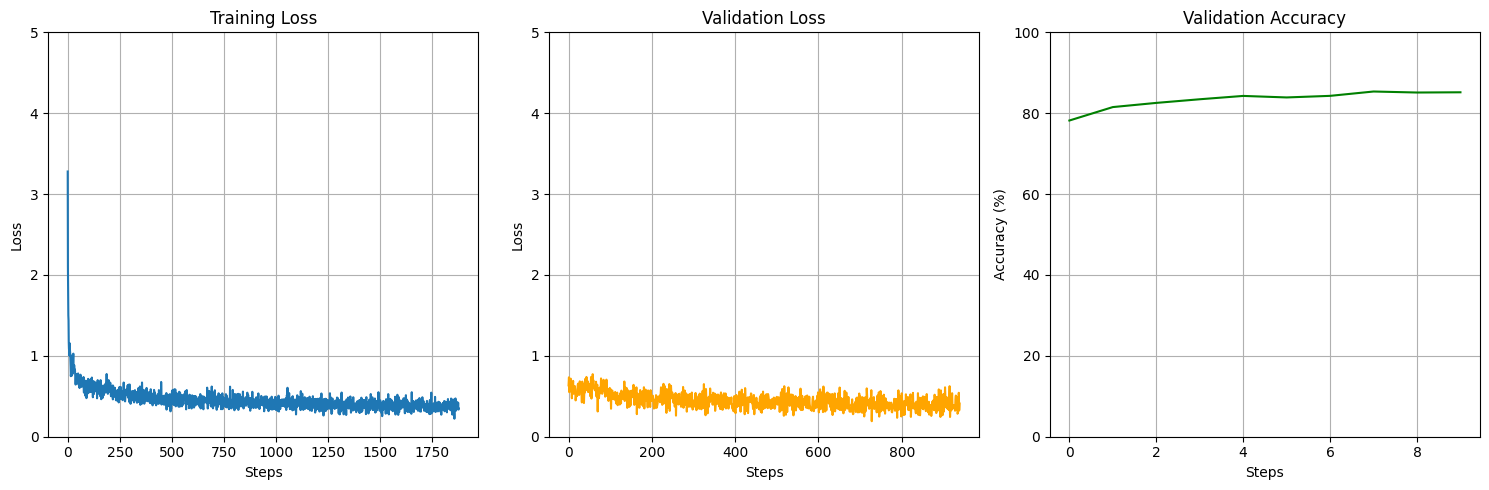

In [ ]:
plot_train_val_metrics(adam_train_losses, adam_val_losses, adam_val_accuracies, option=2, title='Adam with lr=0.001, betas=(0.9, 0.999), eps=1e-8', ymax=5.0)

Looks good so far, no large spike in losses. Let's compare it against the other optimization algorithms.

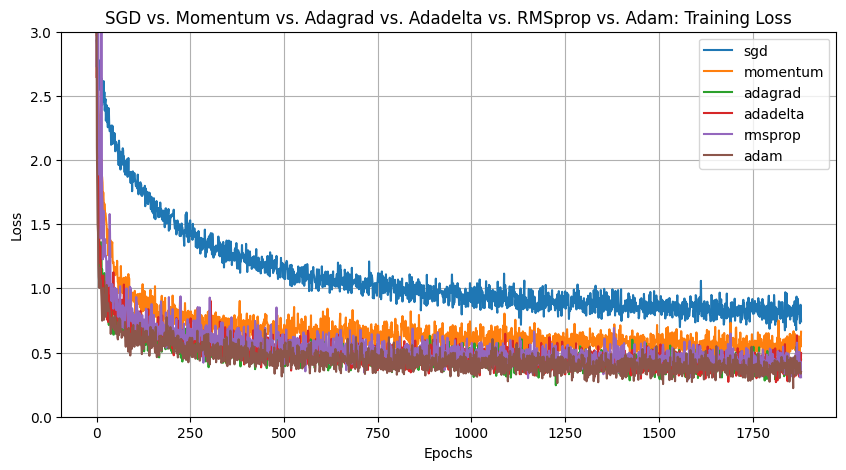

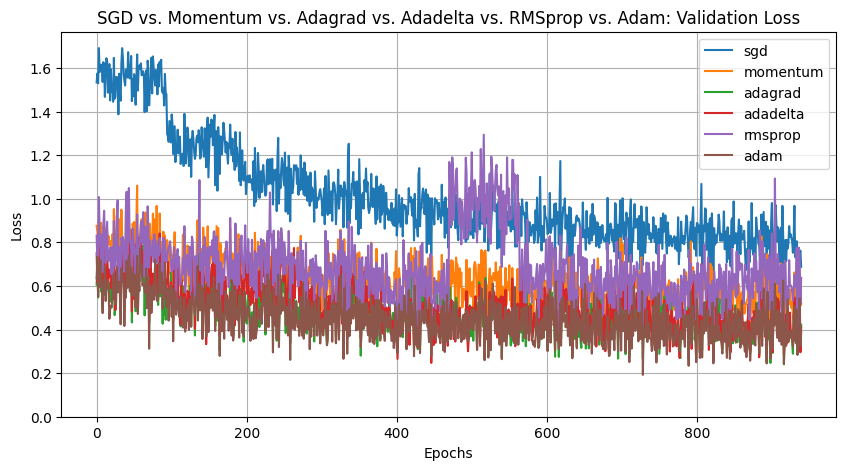

In [ ]:
train_losses = [sgd_train_losses, momentum_train_losses, adagrad_train_losses, adadelta_train_losses, rmsprop_losses[1e-2], adam_train_losses]
labels = ['sgd', 'momentum','adagrad', 'adadelta', 'rmsprop', 'adam']

val_losses = [sgd_val_losses,momentum_val_losses, adagrad_val_losses, adadelta_val_losses, rmsprop_val_losses, adam_val_losses]
val_accuracies = [sgd_val_accuracies,momentum_val_accuracies, adagrad_val_accuracies, adadelta_val_accuracies, rmsprop_val_accuracies, adam_val_accuracies]

plot_losses(train_losses, labels, 'SGD vs. Momentum vs. Adagrad vs. Adadelta vs. RMSprop vs. Adam: Training Loss', ymax=3.0)

plot_losses(val_losses, labels, 'SGD vs. Momentum vs. Adagrad vs. Adadelta vs. RMSprop vs. Adam: Validation Loss')



Adam seems to be in line with Adagrad and Adadelta, though better than RMSprop.

Let's check by zooming in.

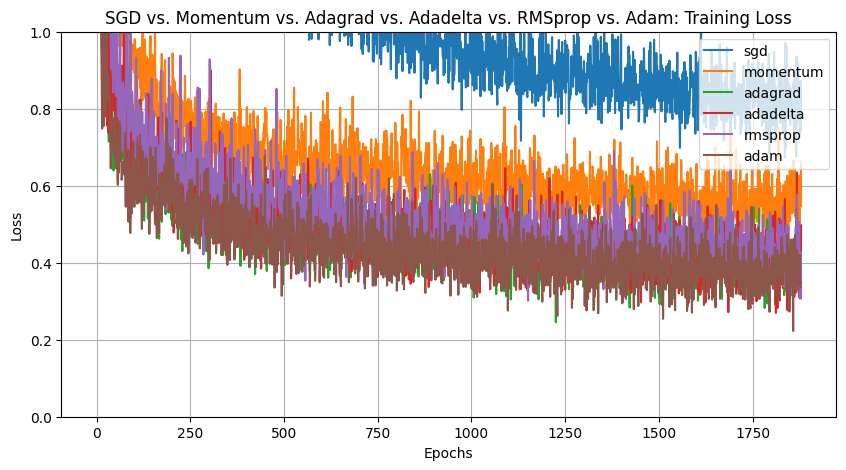

In [ ]:
plot_losses(train_losses, labels, 'SGD vs. Momentum vs. Adagrad vs. Adadelta vs. RMSprop vs. Adam: Training Loss', ymax=1)

Again, all looks pretty equal between Adagrad, Adadelta and Adam.

We can perform a running average over the training losses to see if this helps find a clear winner.

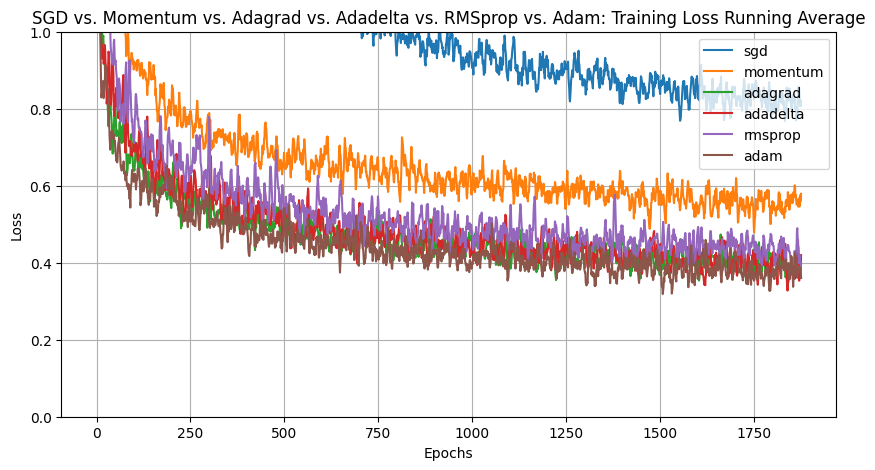

In [ ]:

smoothed_losses = [moving_average(loss) for loss in train_losses]

plot_losses(smoothed_losses, labels, 'SGD vs. Momentum vs. Adagrad vs. Adadelta vs. RMSprop vs. Adam: Training Loss Running Average', ymax=1)

We also compare the validation loss and accuracies of these methods.

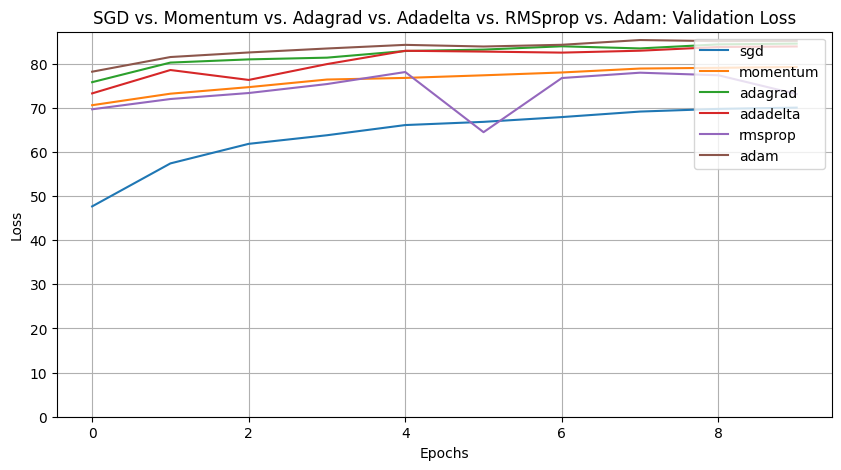

In [ ]:
plot_losses(val_accuracies, labels, 'SGD vs. Momentum vs. Adagrad vs. Adadelta vs. RMSprop vs. Adam: Validation Loss')


### Nope, no clear winner. Looks like Adagrad, Adadelta and Adam are all pretty much equal for this experimental set-up. But the accuracy of Adam is slightly better than others.



### In the following, we directly call pytorch's own optimization module. We will try SGD, adagrad, and adam. We will compare these methods with the implementation above

We see that our implementation is not much slower than pytorch's optimizer.

Training Epoch 1/10: 100%|██████████| 188/188 [00:09<00:00, 20.72it/s]


Epoch: 1 -> train_loss: 1.8096


Validation Epoch 1/10: 100%|██████████| 94/94 [00:02<00:00, 41.40it/s]


Epoch: 1 -> val_loss: 1.4097, val_acc: 54.53%


Training Epoch 2/10: 100%|██████████| 188/188 [00:09<00:00, 20.77it/s]


...

Epoch: 9 -> val_loss: 0.8174, val_acc: 69.78%


Training Epoch 10/10: 100%|██████████| 188/188 [00:09<00:00, 20.60it/s]


Epoch: 10 -> train_loss: 0.8098


Validation Epoch 10/10: 100%|██████████| 94/94 [00:02<00:00, 41.03it/s]


Epoch: 10 -> val_loss: 0.7953, val_acc: 70.58%


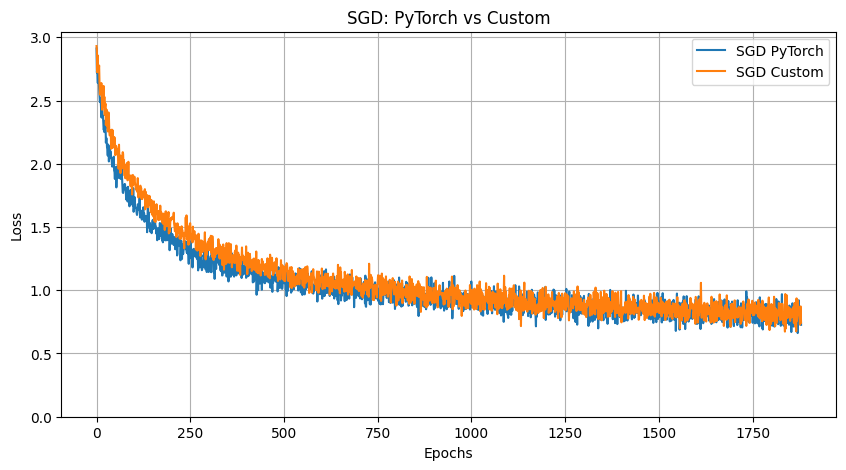

Training Epoch 1/10: 100%|██████████| 188/188 [00:09<00:00, 20.49it/s]


Epoch: 1 -> train_loss: 1.1933


Validation Epoch 1/10: 100%|██████████| 94/94 [00:02<00:00, 41.07it/s]


Epoch: 1 -> val_loss: 0.8439, val_acc: 69.44%


Training Epoch 2/10: 100%|██████████| 188/188 [00:09<00:00, 20.64it/s]


...

Epoch: 9 -> val_loss: 0.5635, val_acc: 79.13%


Training Epoch 10/10: 100%|██████████| 188/188 [00:09<00:00, 20.64it/s]


Epoch: 10 -> train_loss: 0.5568


Validation Epoch 10/10: 100%|██████████| 94/94 [00:02<00:00, 41.06it/s]


Epoch: 10 -> val_loss: 0.5520, val_acc: 80.04%


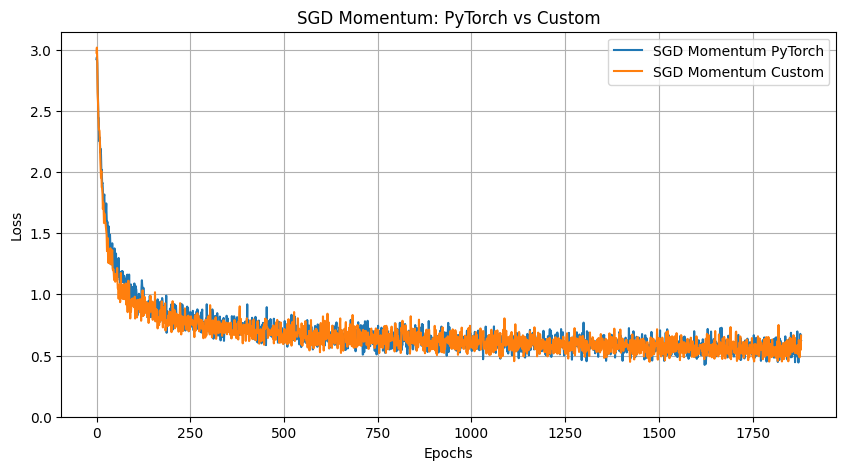

Training Epoch 1/10: 100%|██████████| 188/188 [00:09<00:00, 20.01it/s]


Epoch: 1 -> train_loss: 0.7852


Validation Epoch 1/10: 100%|██████████| 94/94 [00:02<00:00, 40.92it/s]


Epoch: 1 -> val_loss: 0.6539, val_acc: 75.46%


Training Epoch 2/10: 100%|██████████| 188/188 [00:09<00:00, 20.44it/s]


...

Epoch: 9 -> val_loss: 0.5184, val_acc: 80.78%


Training Epoch 10/10: 100%|██████████| 188/188 [00:09<00:00, 20.65it/s]


Epoch: 10 -> train_loss: 0.5115


Validation Epoch 10/10: 100%|██████████| 94/94 [00:02<00:00, 41.14it/s]


Epoch: 10 -> val_loss: 0.5144, val_acc: 80.77%


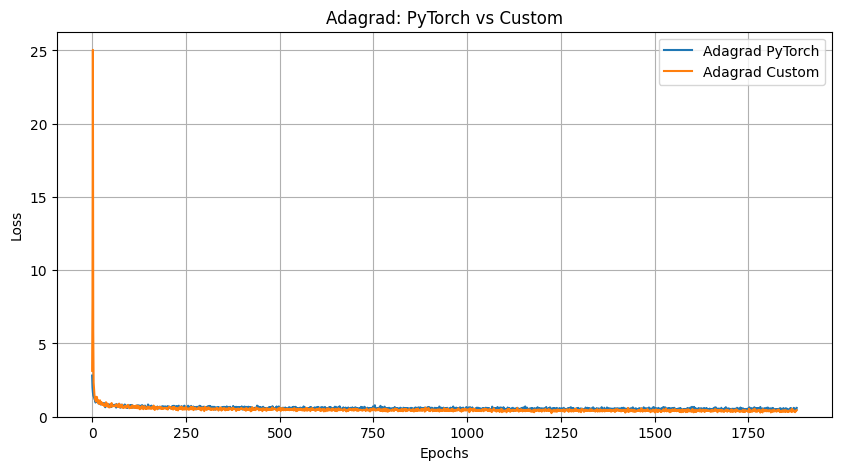

Training Epoch 1/10: 100%|██████████| 188/188 [00:09<00:00, 20.68it/s]


Epoch: 1 -> train_loss: 0.6875


Validation Epoch 1/10: 100%|██████████| 94/94 [00:02<00:00, 41.24it/s]


Epoch: 1 -> val_loss: 0.5543, val_acc: 79.08%


Training Epoch 2/10: 100%|██████████| 188/188 [00:09<00:00, 20.68it/s]


...

Epoch: 9 -> val_loss: 0.3990, val_acc: 85.37%


Training Epoch 10/10: 100%|██████████| 188/188 [00:09<00:00, 20.51it/s]


Epoch: 10 -> train_loss: 0.3907


Validation Epoch 10/10: 100%|██████████| 94/94 [00:02<00:00, 40.95it/s]


Epoch: 10 -> val_loss: 0.4055, val_acc: 84.89%


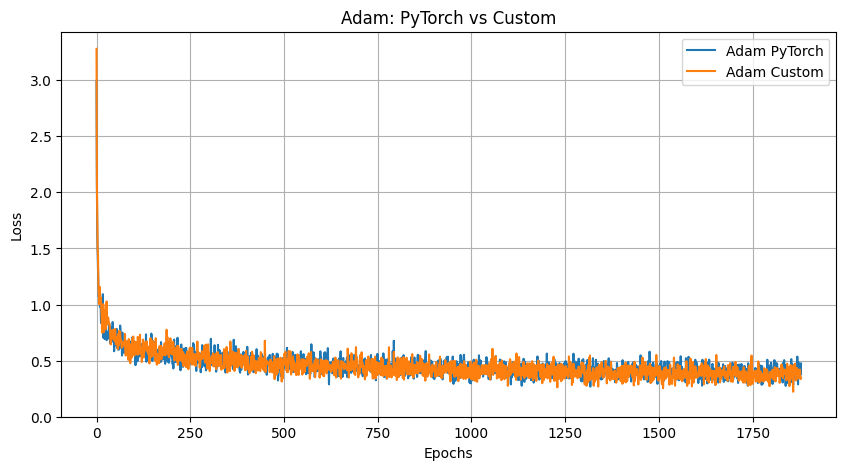

In [ ]:
import torch.optim as optim

# PyTorch SGD
optimizer = optim.SGD(model.parameters(), lr=1e-3)
SGD_pytorch_train_losses, _, _ = train_and_evaluate(model, train_loader, val_loader, optimizer, criterion, device, n_epochs=10)

# Plot PyTorch SGD losses with custom SGD losses
plot_losses([SGD_pytorch_train_losses, sgd_train_losses], ['SGD PyTorch', 'SGD Custom'], title='SGD: PyTorch vs Custom')

# PyTorch SGD with Momentum
optimizer = optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)
SGD_momentum_pytorch_train_losses, _, _ = train_and_evaluate(model, train_loader, val_loader, optimizer, criterion, device, n_epochs=10)

# Plot PyTorch SGD with Momentum losses with custom SGD with Momentum losses
plot_losses([SGD_momentum_pytorch_train_losses, momentum_train_losses], ['SGD Momentum PyTorch', 'SGD Momentum Custom'], title='SGD Momentum: PyTorch vs Custom')

# PyTorch Adagrad
optimizer = optim.Adagrad(model.parameters(), lr=1e-3)
Adagrad_pytorch_train_losses, _, _ = train_and_evaluate(model, train_loader, val_loader, optimizer, criterion, device, n_epochs=10)

# Plot PyTorch Adagrad losses with custom Adagrad losses
plot_losses([Adagrad_pytorch_train_losses, adagrad_train_losses], ['Adagrad PyTorch', 'Adagrad Custom'], title='Adagrad: PyTorch vs Custom')

# PyTorch Adam
optimizer = optim.Adam(model.parameters(), lr=1e-3, betas=(0.9, 0.999))
Adam_pytorch_train_losses, _, _ = train_and_evaluate(model, train_loader, val_loader, optimizer, criterion, device, n_epochs=10)

# Plot PyTorch Adam losses with custom Adam losses
plot_losses([Adam_pytorch_train_losses, adam_train_losses], ['Adam PyTorch', 'Adam Custom'], title='Adam: PyTorch vs Custom')


# Finally, to complete the whole deep learning pipeline, we report the testing error of the Adam-trained model on the testing dataset

We train SGD and Adam for a larger number of epochs and report the accuracy

In [ ]:
def evaluate(model, test_loader, criterion, device):
    """Evaluates the model on the test dataset and returns the average loss and accuracy."""
    model.eval()  # Set the model to evaluation mode
    test_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    with torch.no_grad():  # Disable gradient computation
        for images, labels in tqdm.tqdm(test_loader, desc="Testing"):
            images, labels = images.to(device), labels.to(device)
            predictions = model(images)
            loss = criterion(predictions, labels)
            test_loss += loss.item()

            # Calculate accuracy
            _, predicted_classes = torch.max(predictions, 1)
            correct_predictions += (predicted_classes == labels).sum().item()
            total_predictions += labels.size(0)

    # Calculate average loss and accuracy
    avg_test_loss = test_loss / len(test_loader)
    test_accuracy = 100 * correct_predictions / total_predictions

    print(f"Test Loss: {avg_test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")
    return avg_test_loss, test_accuracy


In [ ]:
sgd_optimizer = optim.SGD(model.parameters(), lr=1e-3)
adam_optimizer = optim.Adam(model.parameters(), lr=1e-3, betas=(0.9, 0.999))
_,_,_ = train_and_evaluate(model, train_loader, val_loader, sgd_optimizer, criterion, device, n_epochs=30)

avg_test_loss, test_accuracy = evaluate(model, test_loader, criterion, device)
print(f"the average test loss and accuracy of SGD are {avg_test_loss:.4f} and {test_accuracy:.4f}%")

_,_,_ = train_and_evaluate(model, train_loader, val_loader, adam_optimizer, criterion, device, n_epochs=30)
avg_test_loss, test_accuracy = evaluate(model, test_loader, criterion, device)
print(f"the average test loss and accuracy of Adam are {avg_test_loss:.4f} and {test_accuracy:.4f}%")


Training Epoch 1/30: 100%|██████████| 188/188 [00:09<00:00, 20.46it/s]


Epoch: 1 -> train_loss: 1.9947


Validation Epoch 1/30: 100%|██████████| 94/94 [00:02<00:00, 40.72it/s]


Epoch: 1 -> val_loss: 1.4913, val_acc: 48.33%


Training Epoch 2/30: 100%|██████████| 188/188 [00:09<00:00, 20.49it/s]


...

Training Epoch 6/30: 100%|██████████| 188/188 [00:09<00:00, 20.55it/s]


Epoch: 6 -> train_loss: 0.4247


Validation Epoch 6/30: 100%|██████████| 94/94 [00:02<00:00, 41.07it/s]


Epoch: 6 -> val_loss: 0.4516, val_acc: 83.06%


Training Epoch 7/30:  67%|██████▋   | 126/188 [00:06<00:03, 20.53it/s]

## Summary

In this notebook we implemented and compared six optimization algorithms from scratch:

| Optimizer | Key Idea | Pros | Cons |
|-----------|----------|------|------|
| **SGD** | Fixed learning rate, full gradient step | Simple, well-understood theory | Slow on ill-conditioned problems |
| **SGD + Momentum** | Accumulates velocity from past gradients | Faster traversal of flat regions | Extra hyperparameter $\gamma$ |
| **Adagrad** | Per-parameter rates via accumulated squared gradients | Handles sparse gradients well | Learning rate decays to zero over time |
| **Adadelta** | Replaces Adagrad's sum with exponential moving average + unit correction | No manual learning rate needed | Similar to RMSProp in practice |
| **RMSProp** | Exponential moving average of squared gradients | Avoids Adagrad's decay; popular in RL | Sensitive to $\epsilon$ |
| **Adam** | Momentum + RMSProp + bias correction | Robust default; stable early training | May generalize slightly worse than tuned SGD |

**Key takeaways:**

- All adaptive methods (Adagrad, Adadelta, RMSProp, Adam) significantly outperformed fixed-rate SGD on this task.
- Adam's bias correction avoids the large initial loss spikes seen with Adagrad and RMSProp.
- No single optimizer dominates universally. The best choice depends on the model, dataset, and compute budget.
- Our from-scratch implementations match PyTorch's built-in optimizers in both correctness and speed.